In [45]:
import importlib
import pandas as pd
import numpy as np
from helpers import preprocessors as helper
from helpers import plotters
import os
importlib.reload(helper)
Soil_analysis_pd = pd.read_csv('Soil_Analysis/Al Moutmir - Soil Analysis.csv', low_memory=False)

COLUMNS_OF_INTEREST = ['Sand%', 'Clay%', 'Total_Silt%','Coarse element %', 'pH_water',
                       'CaCo3 active%', 'C.E.C (meq / 100g)',
                       'CE_ext1 / 5 ms / cm', 'Na2O ppm', 'Cl- ppm', 'Na meq / 100g',
                       'C / N ratio', 'Organic matter%', 'Exchangeable K2O ppm',
                       'P2O5 ehangable Olsen ppm', 'MgO ppm', 'CaO ppm', 'Iron ppm DTPA',
                       'Mn ppm DTPA', 'Cu ppm DTPA', 'Zn ppm DTPA', 'B ppm Hot water']

In [10]:
# Ensure column names are stripped of extra whitespace
Soil_analysis_pd.columns = Soil_analysis_pd.columns.str.strip()
Soil_analysis_pd = Soil_analysis_pd.drop(columns=['Id', 'depth'], errors='ignore')
print(Soil_analysis_pd.columns)
Soil_analysis_pd.dtypes

Index(['Longitude_X', 'Latitude_Y', 'Date', 'Sand%', 'Clay%', 'Total_Silt%',
       'Fine silt%', 'Coarse silt%', 'Coarse element %', 'pH_water',
       'CaCo3%_Total', 'CaCo3 active%', 'C.E.C (meq / 100g)',
       'CE_ext1 / 5 ms / cm', 'Na2O ppm', 'Cl- ppm', 'Na meq / 100g',
       'C / N ratio', 'Organic matter%', 'Exchangeable K2O ppm',
       'P2O5 ehangable Olsen ppm', 'MgO ppm', 'CaO ppm', 'Iron ppm DTPA',
       'Mn ppm DTPA', 'Cu ppm DTPA', 'Zn ppm DTPA', 'B ppm Hot water'],
      dtype='object')


Longitude_X                 float64
Latitude_Y                  float64
Date                         object
Sand%                        object
Clay%                        object
Total_Silt%                  object
Fine silt%                   object
Coarse silt%                 object
Coarse element %             object
pH_water                    float64
CaCo3%_Total                 object
CaCo3 active%                object
C.E.C (meq / 100g)           object
CE_ext1 / 5 ms / cm         float64
Na2O ppm                     object
Cl- ppm                      object
Na meq / 100g               float64
C / N ratio                  object
Organic matter%             float64
Exchangeable K2O ppm         object
P2O5 ehangable Olsen ppm     object
MgO ppm                      object
CaO ppm                      object
Iron ppm DTPA               float64
Mn ppm DTPA                 float64
Cu ppm DTPA                 float64
Zn ppm DTPA                  object
B ppm Hot water             

In [11]:
# Number of lines before filtering
before_count = len(Soil_analysis_pd)
print(f'Number of lines before filtering: {before_count}')

# Drop rows with any NaN or empty strings
filtered_Soil_analysis_pd = Soil_analysis_pd.dropna(how='any')

# Remove rows containing '-' in any column
filtered_Soil_analysis_pd = filtered_Soil_analysis_pd[~filtered_Soil_analysis_pd.isin(['-']).any(axis=1)]

# Number of lines after filtering
after_count = len(filtered_Soil_analysis_pd)
print(f'Number of lines after filtering: {after_count}')

# Display the first few rows
print(filtered_Soil_analysis_pd.head())

Number of lines before filtering: 57334
Number of lines after filtering: 13627
    Longitude_X  Latitude_Y      Date  ... Cu ppm DTPA Zn ppm DTPA B ppm Hot water
0       -2.6313     34.8688  31/12/19  ...         0.8         0.4             0.5
1       -2.2581     34.9366  31/12/19  ...         1.6         1.7             0.6
7       -2.6090     34.8686  31/12/19  ...         1.3         0.6             0.5
16      -6.4668     32.2798  20/11/19  ...         0.9         0.9             0.1
17      -6.5535     32.3150  20/11/19  ...         1.3         1.3             0.4

[5 rows x 28 columns]


In [12]:
# Automatically convert inferred types (optional, keeps string/object tidy)
filtered_Soil_analysis_pd = filtered_Soil_analysis_pd.convert_dtypes()

# Define expected column types
column_types = {
    'float': [
        'Longitude_X', 'Latitude_Y', 'pH_water', 'CaCo3%_Total', 
        'CaCo3 active%', 'C.E.C (meq / 100g)', 'CE_ext1 / 5 ms / cm', 
        'Na2O ppm', 'Cl- ppm', 'Na meq / 100g', 'C / N ratio', 
        'Organic matter%', 'MgO ppm', 'CaO ppm', 'Iron ppm DTPA', 
        'Mn ppm DTPA', 'Cu ppm DTPA', 'Zn ppm DTPA', 'B ppm Hot water'
    ],
    'int': [
        'Sand%', 'Clay%', 'Total_Silt%', 'Fine silt%', 'Coarse silt%', 
        'Coarse element %', 'Exchangeable K2O ppm', 'P2O5 ehangable Olsen ppm'
    ],
    'datetime': ['Date'],
    'string': ['CA', 'Province', 'Crop', 'Water regim']
}

# Apply conversions
for dtype, cols in column_types.items():
    helper.safe_convert(filtered_Soil_analysis_pd, cols, dtype)

# Optional: Check result
print(filtered_Soil_analysis_pd.dtypes)

Longitude_X                        Float64
Latitude_Y                         Float64
Date                        datetime64[ns]
Sand%                                Int64
Clay%                                Int64
Total_Silt%                          Int64
Fine silt%                           Int64
Coarse silt%                         Int64
Coarse element %                     Int64
pH_water                           Float64
CaCo3%_Total                       Float64
CaCo3 active%                      Float64
C.E.C (meq / 100g)                 Float64
CE_ext1 / 5 ms / cm                Float64
Na2O ppm                             Int64
Cl- ppm                            Float64
Na meq / 100g                      Float64
C / N ratio                        Float64
Organic matter%                    Float64
Exchangeable K2O ppm                 Int64
P2O5 ehangable Olsen ppm             Int64
MgO ppm                              Int64
CaO ppm                              Int64
Iron ppm DT

/Users/khalilmisbah/Desktop/CESBIO/AL_Moutmir/helpers/preprocessors.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [13]:
filtered_Soil_analysis_pd.describe()

,Longitude_X,Latitude_Y,Date,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,CaCo3 active%,C.E.C (meq / 100g),CE_ext1 / 5 ms / cm,Na2O ppm,Cl- ppm,Na meq / 100g,C / N ratio,Organic matter%,Exchangeable K2O ppm,P2O5 ehangable Olsen ppm,MgO ppm,CaO ppm,Iron ppm DTPA,Mn ppm DTPA,Cu ppm DTPA,Zn ppm DTPA,B ppm Hot water
count,13627.0,13627.0,13627,13197.0,13101.0,13611.0,13608.0,13341.0,13618.0,13627.0,13627.0,13627.0,13627.0,13627.0,13300.0,13507.0,13627.0,13627.0,13627.0,13609.0,13627.0,10297.0,609.0,13627.0,13627.0,13627.0,13623.0,13627.0
mean,-7.02557,32.756223,2019-11-07 10:51:53.642033920,53.916951,24.152736,24.580119,17.039683,7.894536,6.687179,8.201612,17.972914,4.406641,32.435738,0.291794,160.065865,106.254638,0.416533,10.429141,2.728333,285.724741,99.327805,425.761484,582.801314,5.55972,17.279196,0.753878,0.751648,0.735085
min,-10.1886,28.1396,2019-01-10 00:00:00,1.0,-1.0,1.0,0.0,0.0,0.0,5.8,0.5,0.1,0.5,0.04,16.0,2.8,0.0,0.1,0.2,19.0,3.0,4.0,35.0,0.1,0.1,0.1,0.0,0.0
25%,-8.5525,31.9479,2019-08-27 00:00:00,36.0,10.0,16.0,10.0,4.0,3.0,7.96,1.6,1.2,18.2,0.15,40.0,50.0,0.1,8.6,1.8,165.0,46.0,231.0,376.0,4.0,5.7,0.2,0.2,0.5
50%,-7.3918,32.7225,2019-10-27 00:00:00,55.0,19.0,25.0,16.0,7.0,5.0,8.3,21.0,4.0,28.7,0.2,84.0,63.3,0.2,10.2,2.5,243.0,81.0,381.0,577.0,4.0,11.1,0.4,0.4,0.5
75%,-5.6036,33.82005,2020-01-16 00:00:00,72.0,35.0,31.0,22.0,10.0,8.0,8.54,28.1,6.0,43.5,0.31,199.0,115.5,0.4,11.3,3.4,362.0,132.0,597.0,768.0,4.5,22.1,0.8,0.7,0.9
max,-1.9264,35.4799,2020-12-17 00:00:00,100.0,97.0,88.0,76.0,34.0,85.0,9.88,91.5,20.1,182.2,2.92,999.0,987.2,55.5,34.8,10.2,957.0,867.0,999.0,999.0,191.4,195.1,92.4,109.4,60.0
std,1.775098,1.239032,NaN,24.409611,18.273168,11.854535,10.17317,4.483776,5.18856,0.495879,13.611475,3.774962,18.733499,0.305529,189.63249,113.08977,1.141696,2.999261,1.227824,170.314822,77.149603,245.515237,236.168898,5.281634,19.104002,1.629883,1.822111,0.804814


In [14]:
# Export the describe() output to a CSV file on the desktop
describe_output = filtered_Soil_analysis_pd.describe()
describe_output.to_csv('/Users/khalilmisbah/Desktop/filtered_Soil_analysis_describe.csv')

In [15]:
filtered_Soil_analysis_pd = filtered_Soil_analysis_pd[filtered_Soil_analysis_pd['Clay%'] != -1.0]

In [16]:
filtered_Soil_analysis_pd.to_csv('Soil_Analysis/Soil_analysis_filtered.csv', index=False)

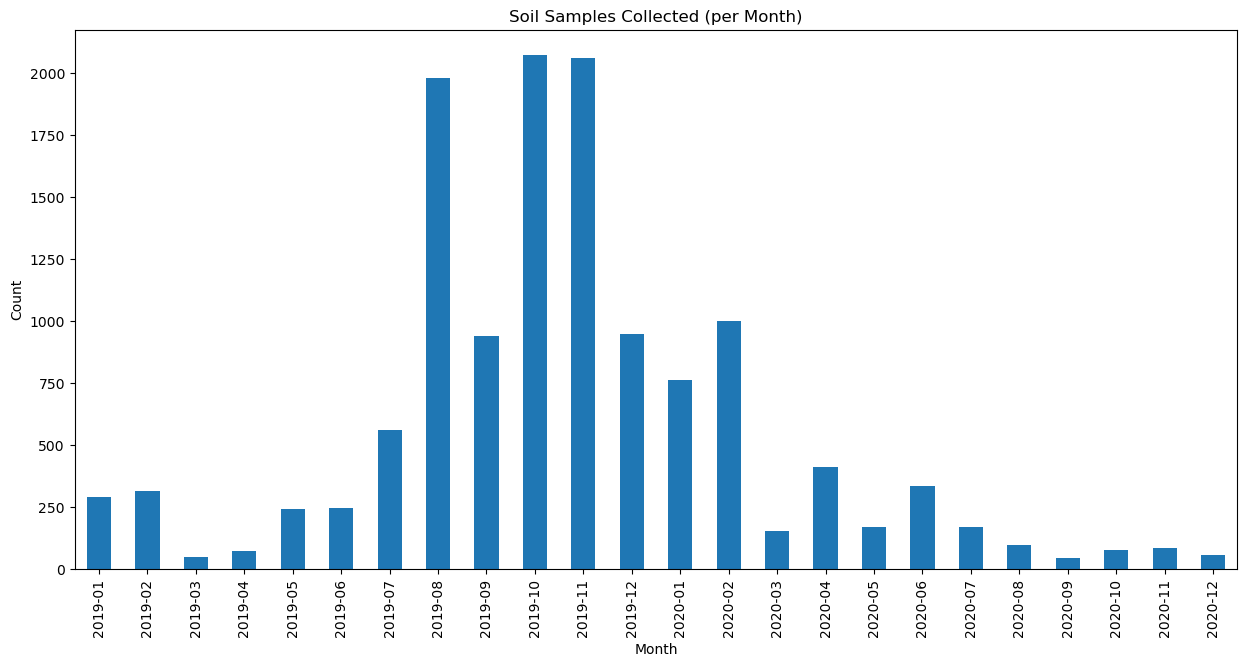

In [17]:
import matplotlib.pyplot as plt

# Aggregate by month
filtered_Soil_analysis_pd['Month'] = filtered_Soil_analysis_pd['Date'].dt.to_period('M')
monthly_counts = filtered_Soil_analysis_pd['Month'].value_counts().sort_index()

# Plot the barplot
plt.figure(figsize=(15, 7))
monthly_counts.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Soil Samples Collected (per Month)')
plt.show()

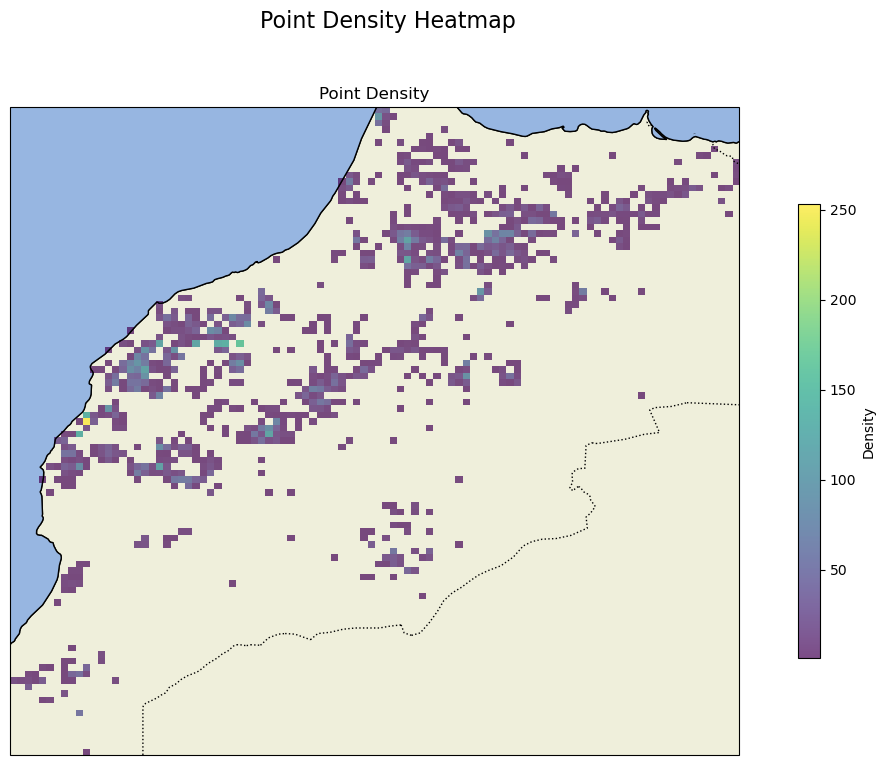

In [20]:
plotters.plot_density_heatmap(filtered_Soil_analysis_pd, single_plot=True, colorbar_mode='continuous')

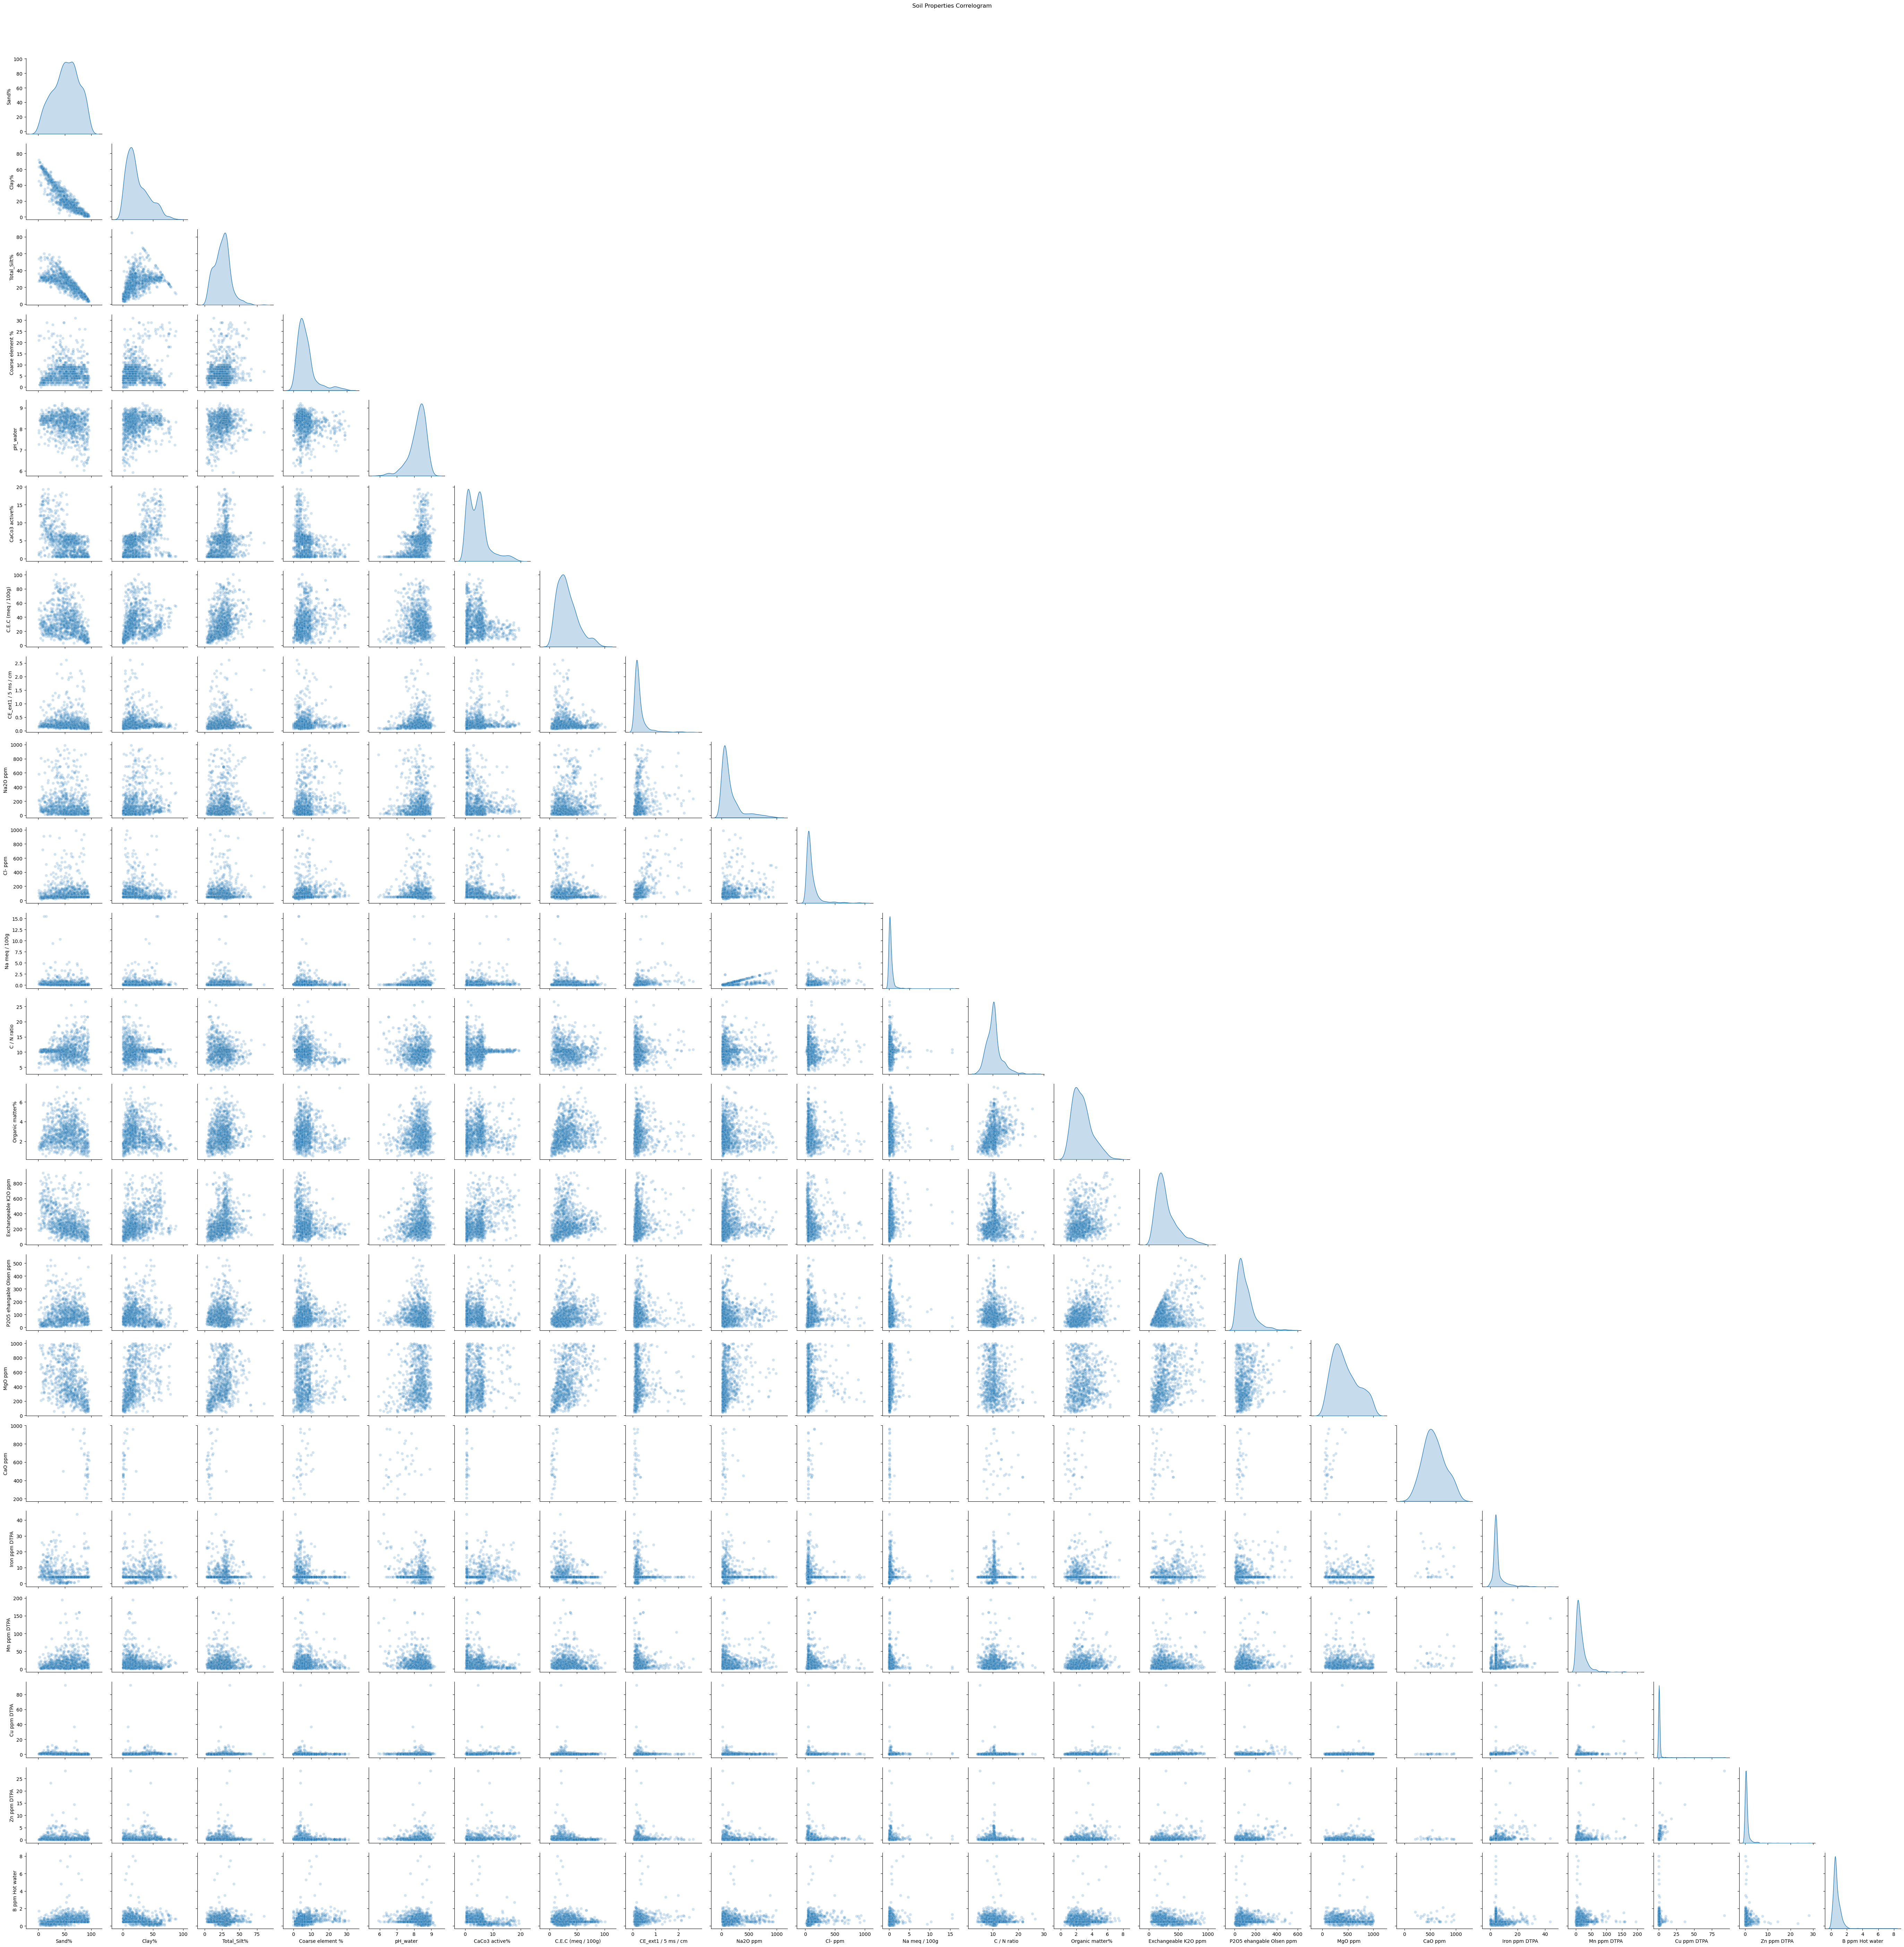

In [21]:
plotters.plot_correlogram(filtered_Soil_analysis_pd, COLUMNS_OF_INTEREST, title='Soil Properties Correlogram')

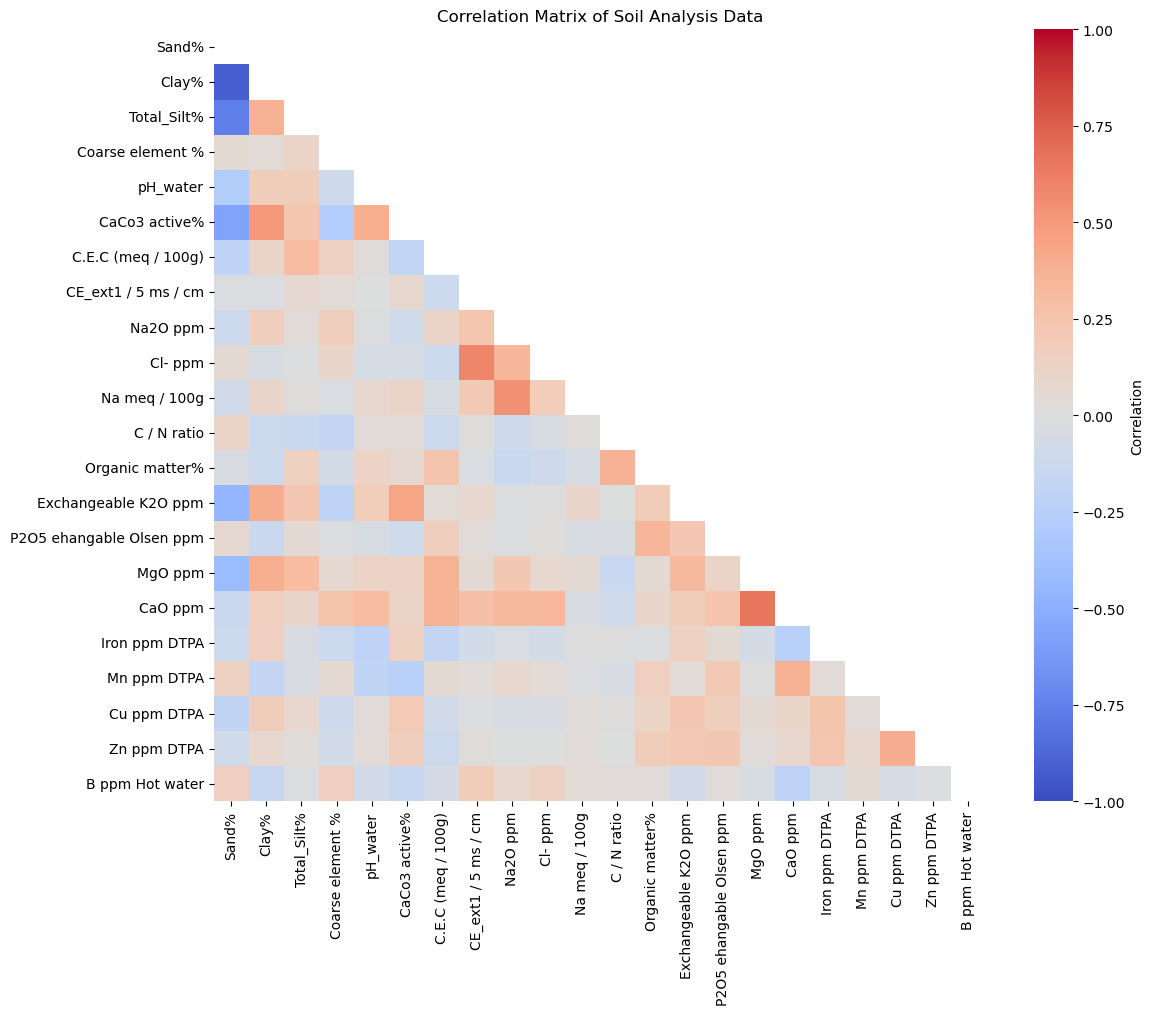

In [22]:
plotters.plot_correlation_heatmap(filtered_Soil_analysis_pd, COLUMNS_OF_INTEREST, 'Correlation Matrix of Soil Analysis Data')


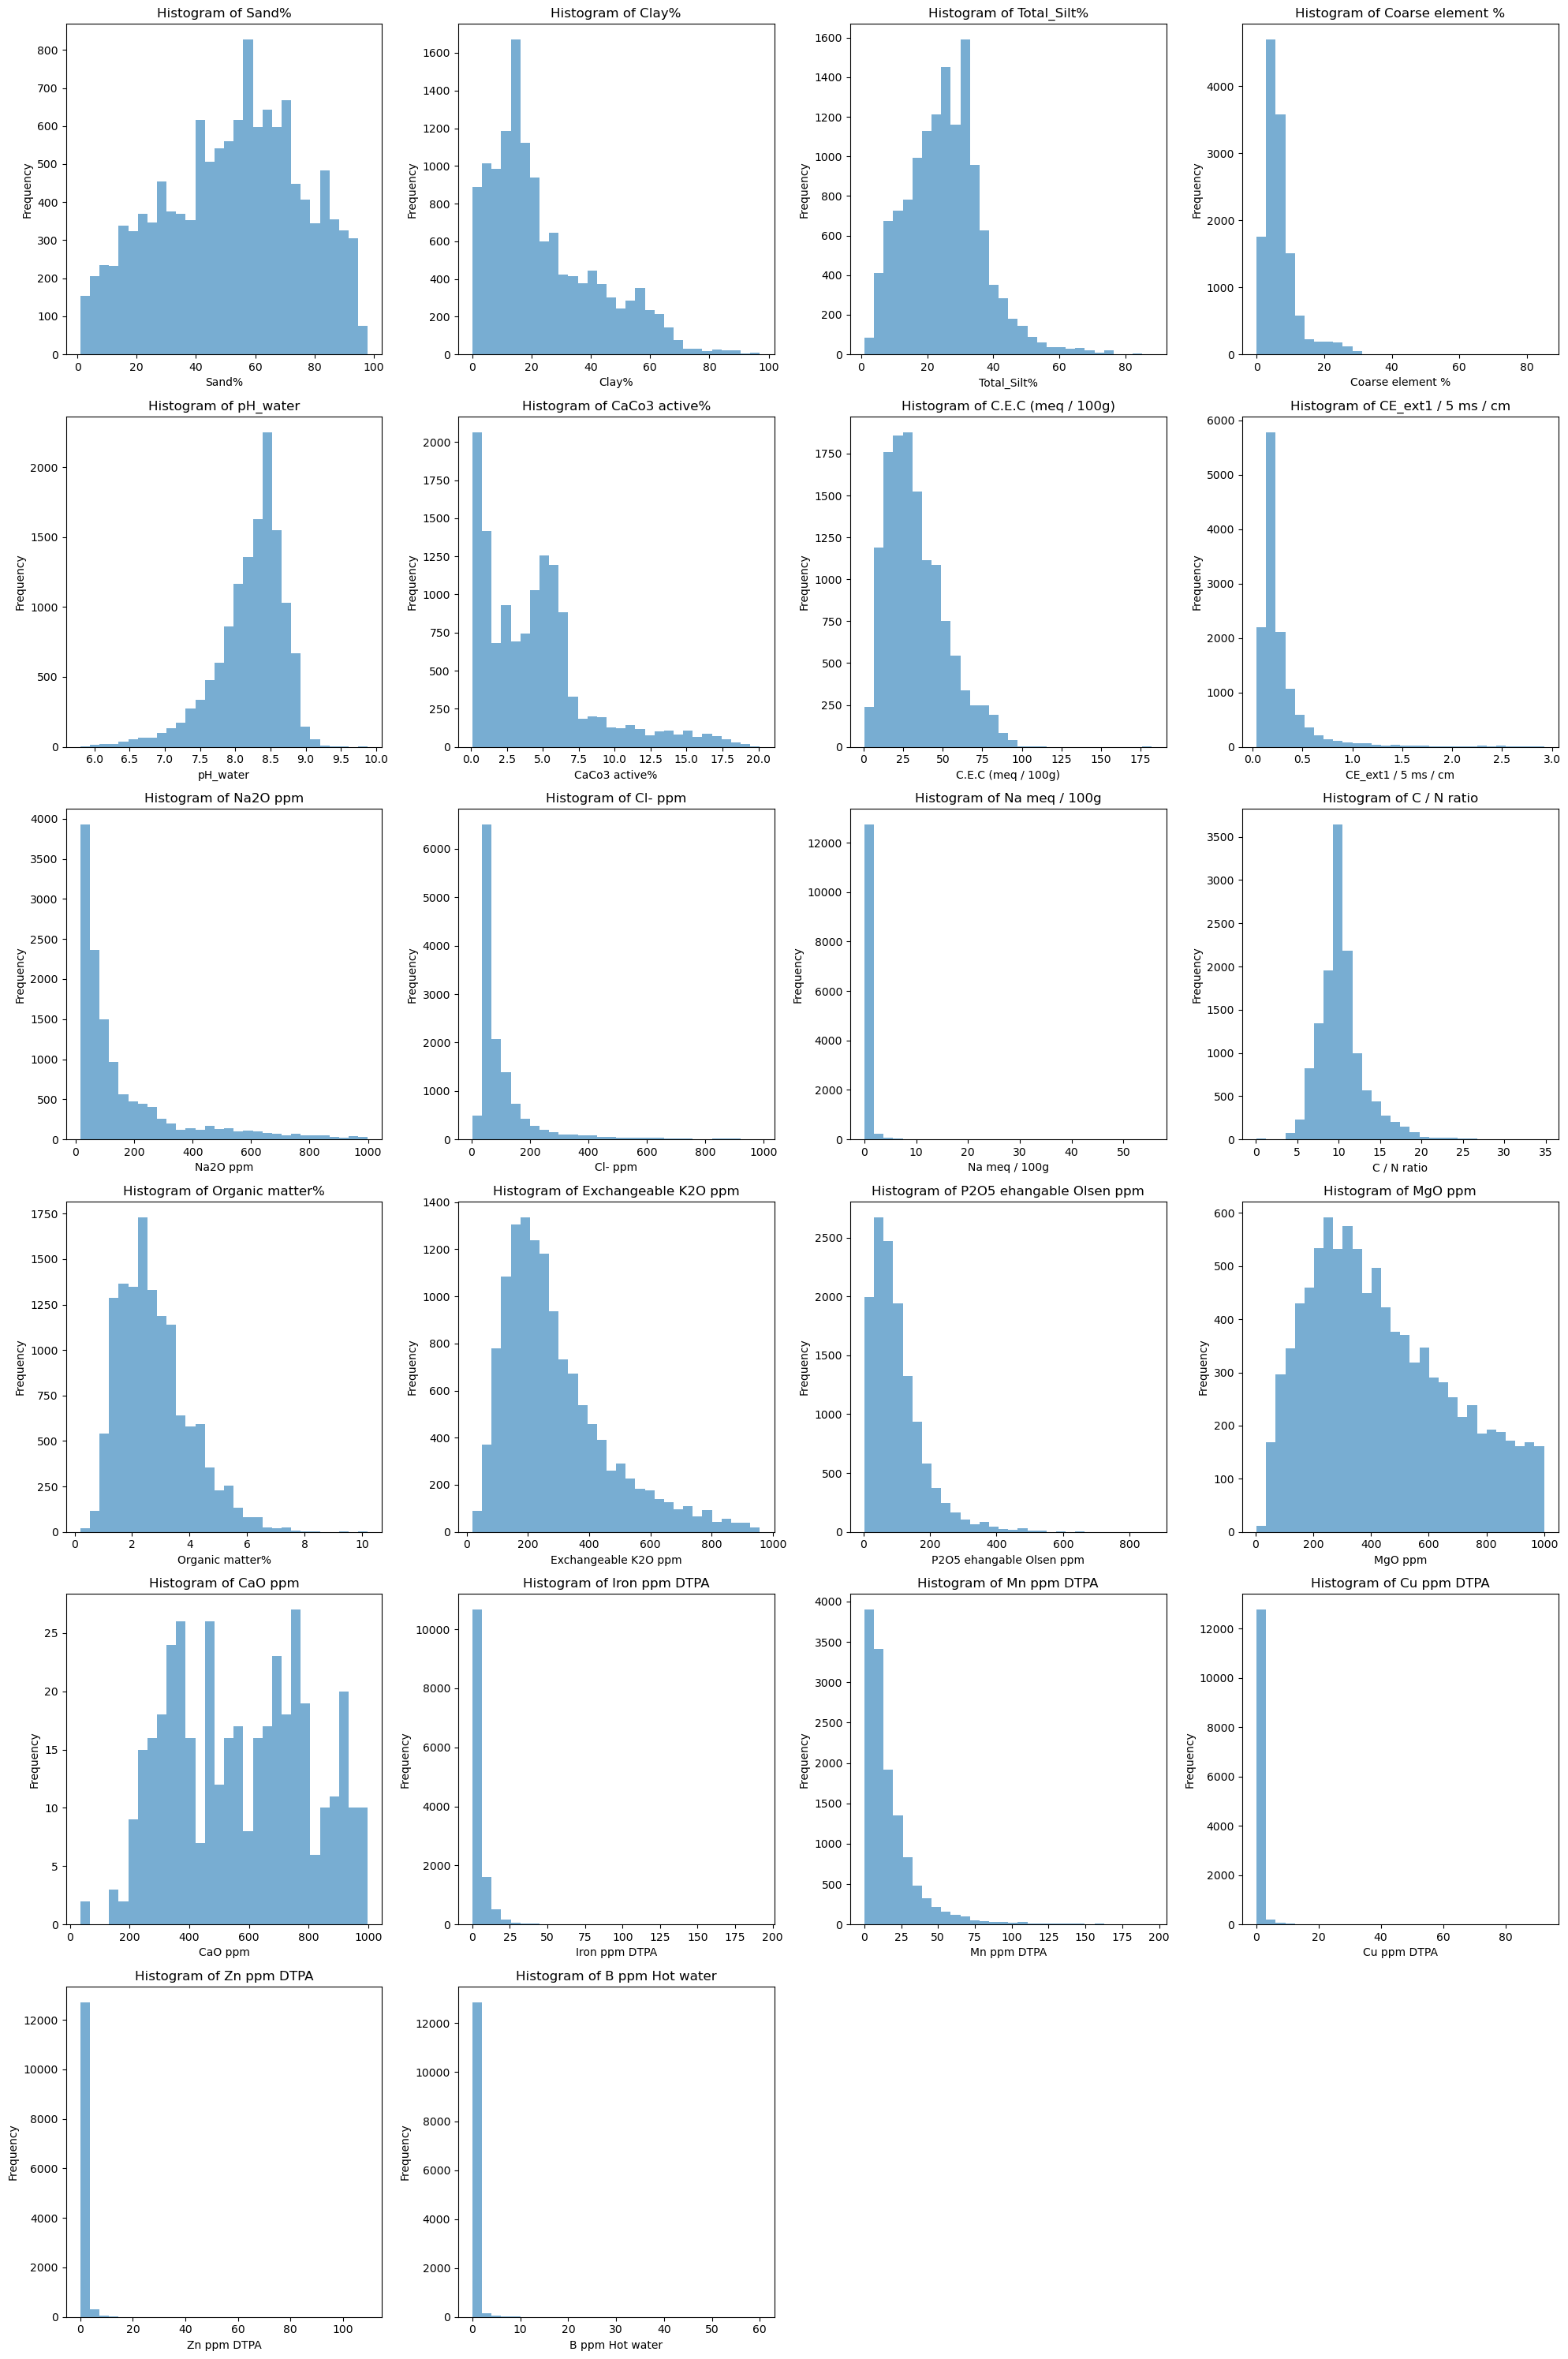

In [23]:
plotters.plot_multiple_datasets(filtered_Soil_analysis_pd, COLUMNS_OF_INTEREST, kind='hist', bins=30)

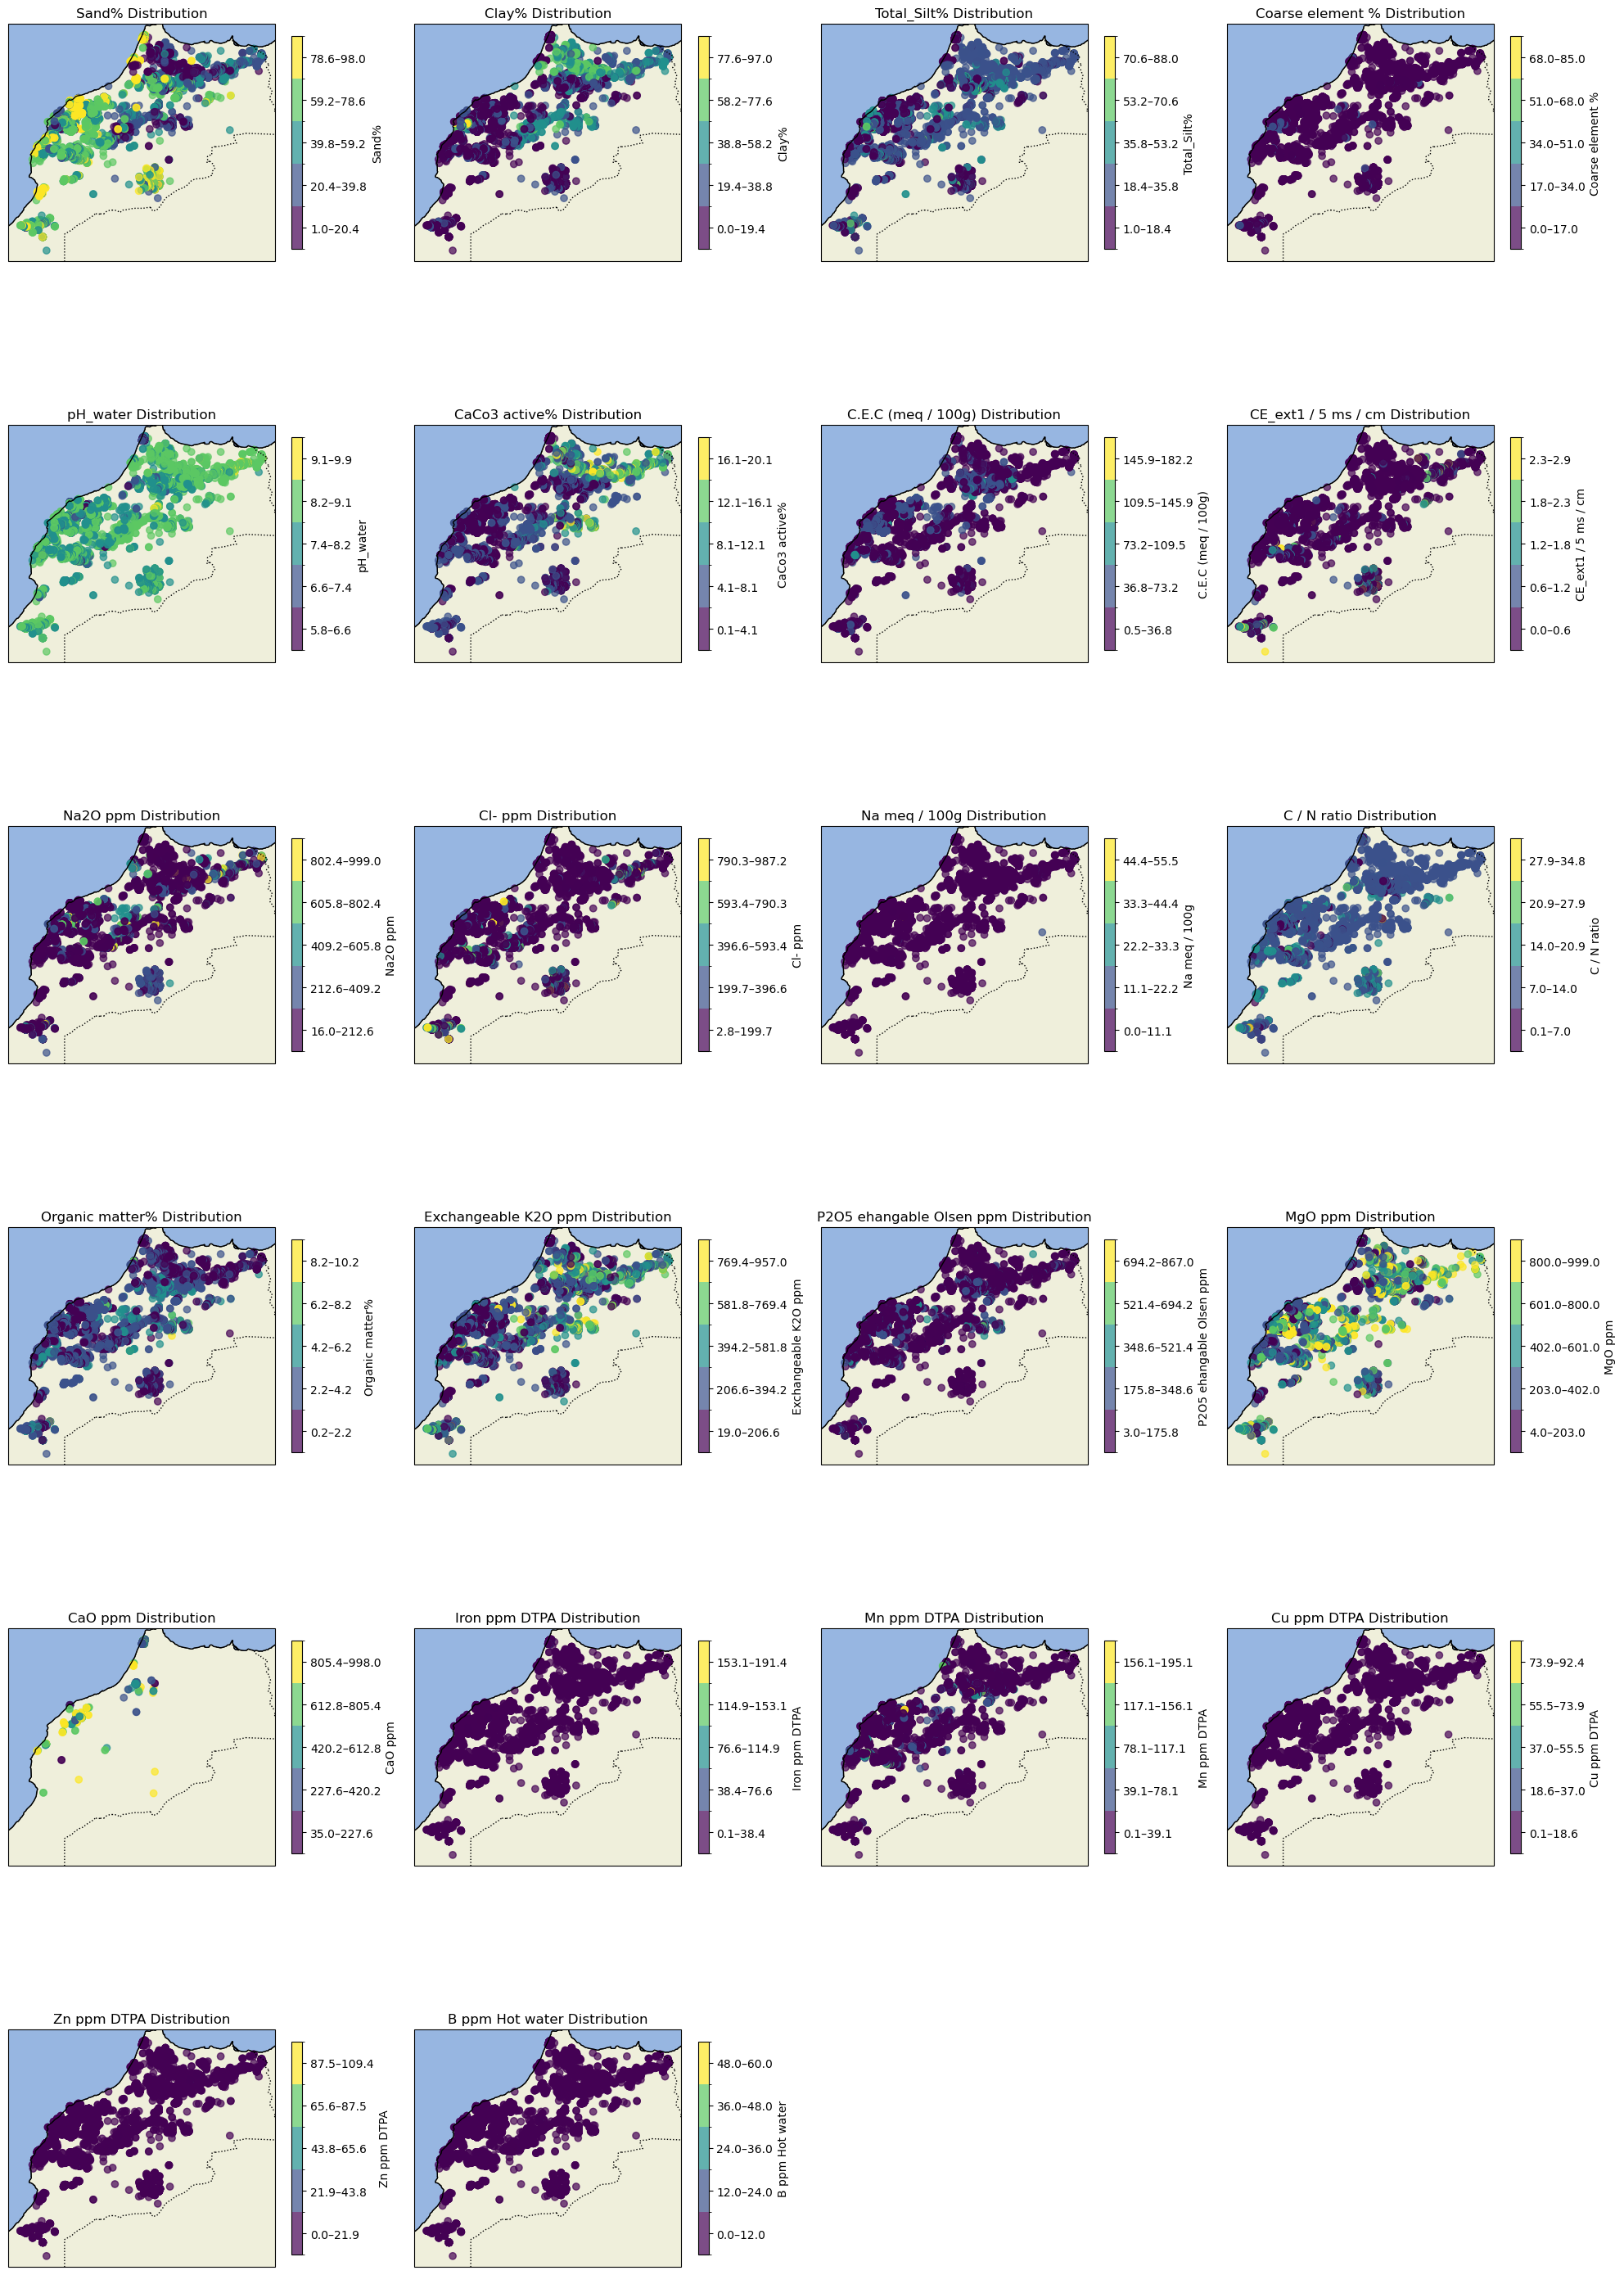

In [24]:
plotters.plot_soil_maps(filtered_Soil_analysis_pd, COLUMNS_OF_INTEREST, group_colormap=True)

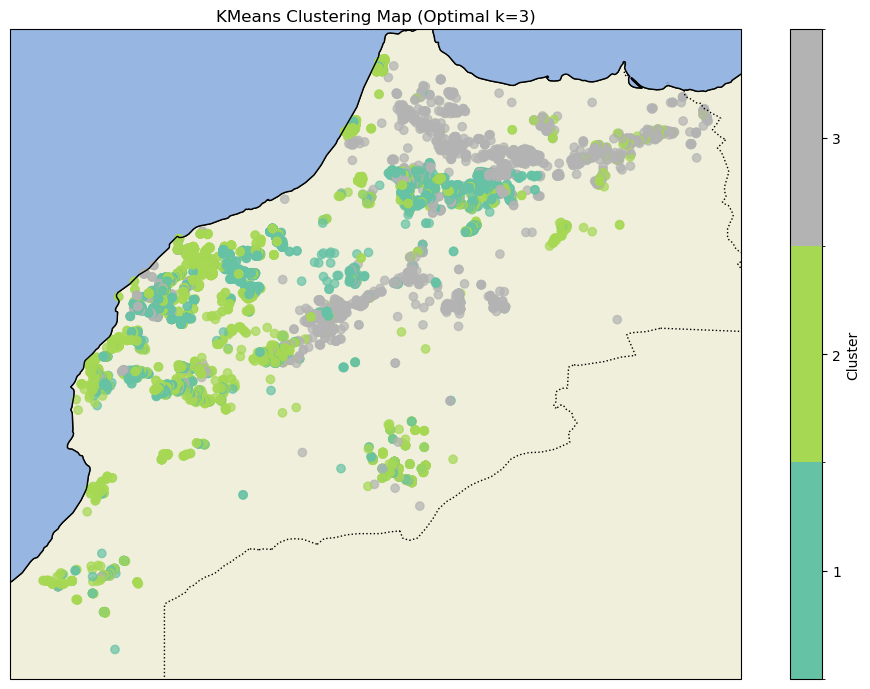

In [26]:
helper.kmeans_clustering_map(filtered_Soil_analysis_pd, feature_cols=['Sand%', 'Clay%', 'Total_Silt%',
                       'CaCo3 active%', 'C.E.C (meq / 100g)', 'Organic matter%'], cmap='Set2', show_cluster_labels=False)


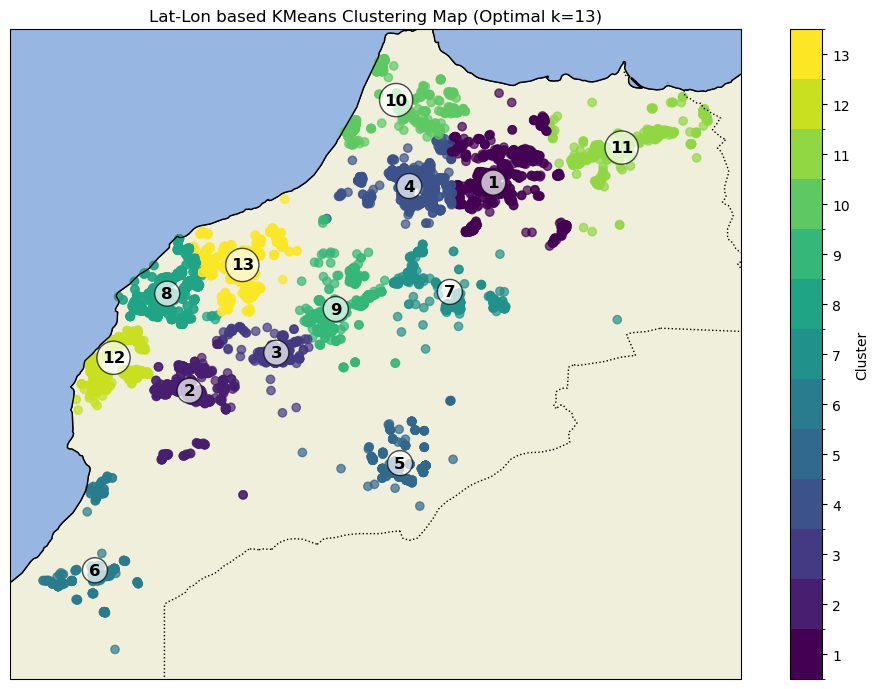

In [27]:
helper.kmeans_clustering_map(filtered_Soil_analysis_pd, feature_cols=['Longitude_X', 'Latitude_Y'], cmap='viridis', title='Lat-Lon based KMeans Clustering Map')

In [28]:
latlon_clustered= helper.kmeans_clustering_map(filtered_Soil_analysis_pd, feature_cols=['Longitude_X', 'Latitude_Y'], show_map=False, return_df=True)

In [29]:
print(len(latlon_clustered[latlon_clustered['KMeans_Cluster'] == 8]))
print(len(latlon_clustered))

2087
13095


In [30]:
filtered_Soil_analysis_pd.to_csv('Morocco_soil_analysis_filtered.csv', index=False)

In [31]:
# Filter the data for cluster corresponding to Doukkala region in KMeans
doukkala_Soil_analysis_pd = latlon_clustered[latlon_clustered['KMeans_Cluster'].isin([8])]
restof_morocco_Soil_analysis_pd = latlon_clustered[~latlon_clustered['KMeans_Cluster'].isin([8])]

# Export the filtered data to a CSV file
doukkala_Soil_analysis_pd.to_csv('doukkala_soil_analysis.csv', index=False)

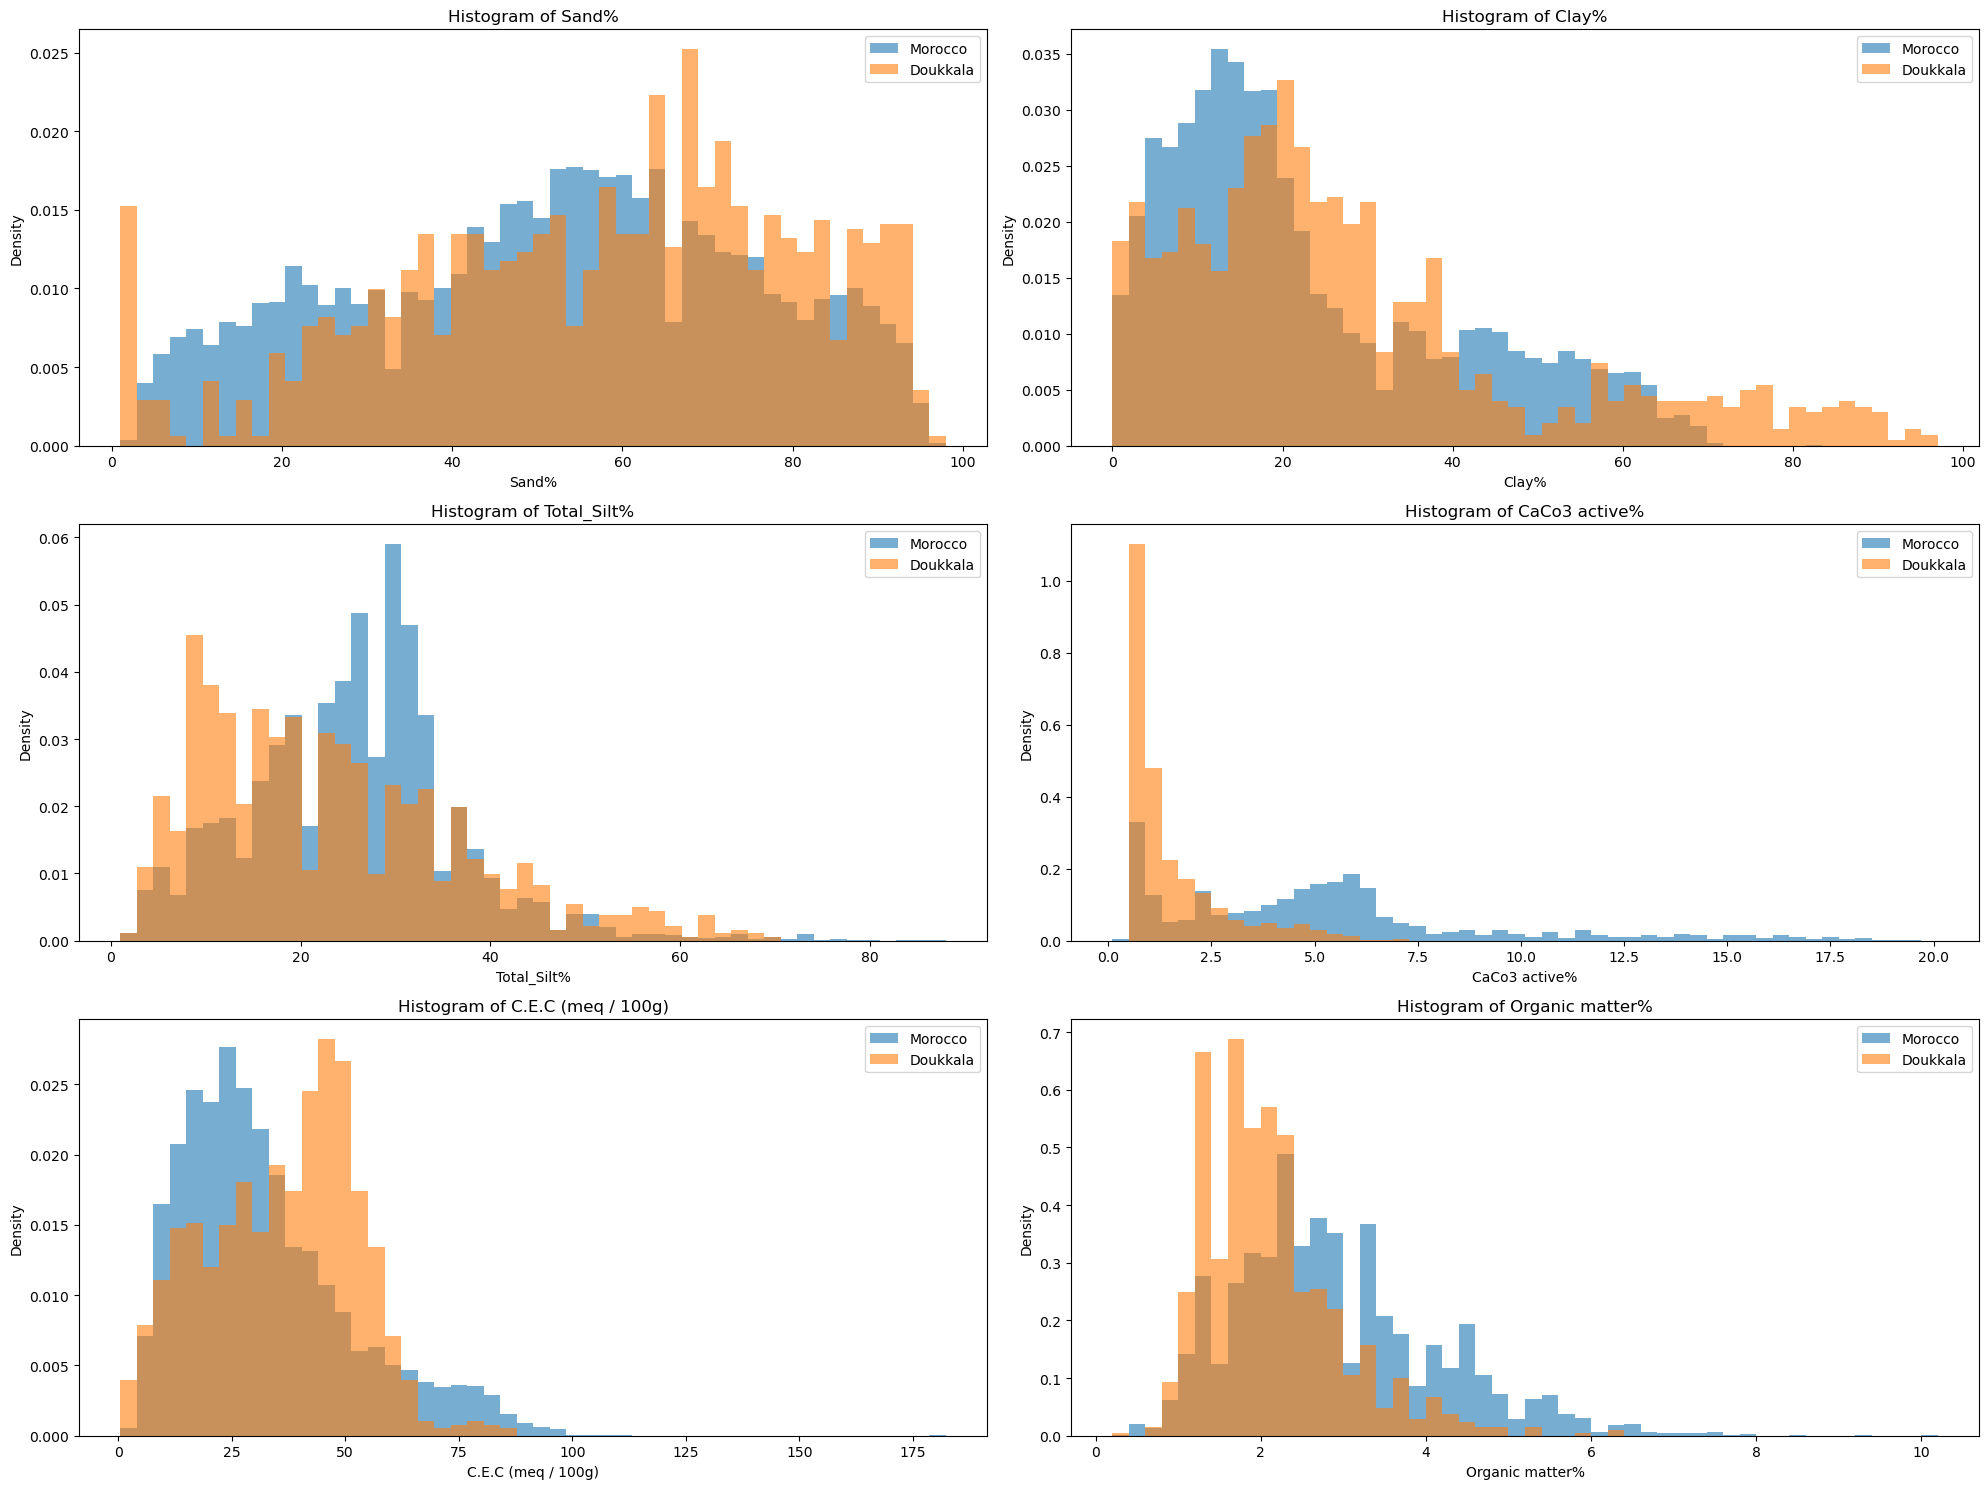

In [33]:
plotters.plot_multiple_datasets(
    dfs=[restof_morocco_Soil_analysis_pd, doukkala_Soil_analysis_pd],
    columns=['Sand%', 'Clay%', 'Total_Silt%',
                       'CaCo3 active%', 'C.E.C (meq / 100g)', 'Organic matter%'],
    dataset_labels=['Morocco', 'Doukkala'],
    kind='hist',
    bins=50 ,ncols=2)

In [42]:
image_path = '/Users/khalilmisbah/Desktop/Khalil/merged_output_nohistmatch.bip'
mask_path = '/Users/khalilmisbah/Desktop/Khalil/sol_mask_nohm_severe2/merged_output_nohistmatch_soildom_mask.dat'
# Example if your nodata value is 0 or -9999
doukkala_spectra, doukkala_with_uuid = helper.extract_spectral_values(
    image_path=image_path,
    mask_path=mask_path,
    df=doukkala_Soil_analysis_pd,
    nodata_value=-9999,
    verbose=True)

# Replace -9999 with NaN
doukkala_spectra.replace(-9999, np.nan, inplace=True)

# Interpolate NaN values for columns starting from the 4th column onwards
doukkala_spectra.iloc[:, 4:] = doukkala_spectra.iloc[:, 4:].interpolate(method='linear', axis=1, limit=5, limit_direction='both')

# Save to CSV (optional)
doukkala_spectra.to_csv("doukkla_spectra_uuid.csv", index=False)
doukkala_with_uuid.to_csv("doukkala_soildata_uuid.csv", index=False)
doukkala_spectra.head()


Extracting: 100%|██████████| 2087/2087 [00:26<00:00, 78.85it/s] 


,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,Band_14,Band_15,Band_16,Band_17,Band_18,Band_19,Band_20,Band_21,Band_22,Band_23,Band_24,Band_25,Band_26,Band_27,Band_28,Band_29,Band_30,Band_31,Band_32,Band_33,Band_34,Band_35,Band_36,Band_37,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,6e64e891-40eb-4a00-a0e6-4978dc971b06,32.5383,-8.4159,0.089473,0.084482,0.088831,0.088680,0.091020,0.097829,0.098462,0.098100,0.098592,0.104166,0.103433,0.108716,0.108465,0.115746,0.114701,0.119241,0.125839,0.134677,0.140090,0.145865,0.151479,0.159554,0.166724,0.175924,0.181056,0.188789,0.193389,0.199013,0.204707,0.208011,0.210944,0.213394,0.220706,0.223829,0.226912,0.237337,0.240752,...,0.402932,0.393866,0.393322,0.393594,0.394470,0.384895,0.378716,0.380184,0.382208,0.376740,0.368905,0.362880,0.363046,0.328782,0.299607,0.333244,0.341434,0.317053,0.297832,0.231185,0.232227,0.186553,0.179712,0.181227,0.176090,0.191134,0.162337,0.124866,0.123884,0.164728,0.129659,0.144998,0.066587,0.096354,0.115741,0.079606,0.046893,0.025198,0.012901,0.013043
1,98d1ca63-779e-49d1-8a4c-9649d75d1b45,32.5251,-8.4336,0.094475,0.094354,0.099155,0.099366,0.103905,0.107049,0.110373,0.109991,0.111809,0.117594,0.118598,0.122927,0.123569,0.130750,0.130921,0.133974,0.141667,0.149320,0.154211,0.159423,0.164364,0.172268,0.178585,0.185575,0.188668,0.198360,0.200117,0.204958,0.210643,0.214610,0.217341,0.218697,0.226219,0.230176,0.232245,0.241987,0.245653,...,0.410673,0.400317,0.401169,0.402873,0.395097,0.391179,0.391239,0.384836,0.377995,0.380456,0.379805,0.365366,0.359282,0.335978,0.306886,0.339978,0.346216,0.331149,0.304791,0.234357,0.234428,0.194140,0.175392,0.178694,0.181760,0.199785,0.162846,0.129079,0.127351,0.172954,0.132902,0.138572,0.070777,0.095573,0.112332,0.076210,0.057213,0.022073,0.002261,0.015647
2,dfa879b3-cdb5-4bd2-b052-eeade1486426,32.5532,-8.5045,0.094917,0.096162,0.095238,0.093611,0.103222,0.105713,0.105151,0.104026,0.105733,0.112120,0.110092,0.114531,0.117112,0.124975,0.125518,0.126984,0.134968,0.143555,0.146578,0.149360,0.152895,0.158007,0.161934,0.167889,0.169657,0.175150,0.177380,0.181387,0.185515,0.186800,0.189602,0.190667,0.198129,0.200268,0.202046,0.211566,0.210853,...,0.299240,0.297536,0.298447,0.295050,0.298341,0.290588,0.290849,0.289653,0.288209,0.292139,0.286079,0.280244,0.277983,0.248477,0.226262,0.254241,0.260029,0.248525,0.225966,0.174209,0.171995,0.137956,0.125304,0.123730,0.126736,0.131671,0.111077,0.095620,0.084116,0.111681,0.090590,0.103159,0.044171,0.060397,0.072292,0.055734,0.032607,0.011966,0.004462,0.015848
3,8c2513d1-5e00-49af-a2da-eb637047d3e8,32.4945,-8.3031,0.106326,0.103935,0.110664,0.110172,0.112854,0.118759,0.122666,0.123770,0.124072,0.129756,0.132940,0.137318,0.138383,0.146016,0.147221,0.149681,0.157545,0.168532,0.176145,0.183225,0.189291,0.199374,0.209498,0.218566,0.223889,0.232878,0.237417,0.241826,0.249288,0.252381,0.255023,0.257825,0.264965,0.269203,0.272568,0.279427,0.284820,...,0.434155,0.427325,0.429539,0.430888,0.431243,0.425266,0.431196,0.426023,0.419928,0.419739,0.412424,0.403264,0.397393,0.368917,0.328131,0.365354,0.374929,0.359022,0.328214,0.262988,0.264301,0.215231,0.196341,0.198211,0.204804,0.220652,0.181322,0.145744,0.150407,0.182221,0.148360,0.159012,0.080246,0.118818,0.125446,0.093040,0.063261,0.012463,0.002734,0.006592
4,25aebdba-9559-407f-8926-c5d19471d5ff,32.4945,-8.3031,0.106326,0.103935,0.110664,0.110172,0.112854,0.118759,0.122666,0.123770,0.124072,0.129756,0.132940,0.137318,0.138383,0.146016,0.147221,0.149681,0.157545,0.168532,0.176145,0.183225,0.189291,0.199374,0.209498,0.218566,0.223889,0.232878,0.237417,0.241826,0.249

In [43]:
# Read the CSV file without column names
bands_df = pd.read_csv('bandsList.csv', header=None)

# Create a dictionary associating key from column 1 to value from column 2
bands_dict = dict(zip(bands_df[0], bands_df[1]))

# Extract the band values from bands_df
band_values = bands_df[1].astype(float)

# Define the ranges to filter
ranges = [
    (None, 456),  # ≤456
    (719, 739),   # 719–739
    (760, 770),   # 760–770
    (813, 813),   # 813
    (951, 951),   # 951
    (962, 962),   # 962
    (973, 973),   # 973
    (855, 960),   # 855–960
    (1120, 1163), # 1120–1163
    (1251, 1284), # 1251–1284
    (1317, 1534), # 1317–1534
    (1765, 2027), # 1765–2027
    (2350, None)  # ≥2350
]
# Create a new DataFrame to store the filtered spectra
modified_doukkala_spectra = helper.drop_junk_spectra(doukkala_spectra, bands_df, ranges)
display(modified_doukkala_spectra.head())

,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,Band_14,Band_15,Band_16,Band_17,Band_18,Band_19,Band_20,Band_21,Band_22,Band_23,Band_24,Band_25,Band_26,Band_27,Band_28,Band_29,Band_30,Band_31,Band_32,Band_33,Band_34,Band_35,Band_36,Band_37,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,6e64e891-40eb-4a00-a0e6-4978dc971b06,32.5383,-8.4159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.098100,0.098592,0.104166,0.103433,0.108716,0.108465,0.115746,0.114701,0.119241,0.125839,0.134677,0.140090,0.145865,0.151479,0.159554,0.166724,0.175924,0.181056,0.188789,0.193389,0.199013,0.204707,0.208011,0.210944,0.213394,0.220706,0.223829,0.226912,0.237337,0.240752,...,0.402932,0.393866,0.393322,0.393594,0.394470,0.384895,0.378716,0.380184,0.382208,0.376740,0.368905,0.362880,0.363046,0.328782,0.299607,0.333244,0.341434,0.317053,0.297832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,98d1ca63-779e-49d1-8a4c-9649d75d1b45,32.5251,-8.4336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.109991,0.111809,0.117594,0.118598,0.122927,0.123569,0.130750,0.130921,0.133974,0.141667,0.149320,0.154211,0.159423,0.164364,0.172268,0.178585,0.185575,0.188668,0.198360,0.200117,0.204958,0.210643,0.214610,0.217341,0.218697,0.226219,0.230176,0.232245,0.241987,0.245653,...,0.410673,0.400317,0.401169,0.402873,0.395097,0.391179,0.391239,0.384836,0.377995,0.380456,0.379805,0.365366,0.359282,0.335978,0.306886,0.339978,0.346216,0.331149,0.304791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dfa879b3-cdb5-4bd2-b052-eeade1486426,32.5532,-8.5045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.104026,0.105733,0.112120,0.110092,0.114531,0.117112,0.124975,0.125518,0.126984,0.134968,0.143555,0.146578,0.149360,0.152895,0.158007,0.161934,0.167889,0.169657,0.175150,0.177380,0.181387,0.185515,0.186800,0.189602,0.190667,0.198129,0.200268,0.202046,0.211566,0.210853,...,0.299240,0.297536,0.298447,0.295050,0.298341,0.290588,0.290849,0.289653,0.288209,0.292139,0.286079,0.280244,0.277983,0.248477,0.226262,0.254241,0.260029,0.248525,0.225966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8c2513d1-5e00-49af-a2da-eb637047d3e8,32.4945,-8.3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.123770,0.124072,0.129756,0.132940,0.137318,0.138383,0.146016,0.147221,0.149681,0.157545,0.168532,0.176145,0.183225,0.189291,0.199374,0.209498,0.218566,0.223889,0.232878,0.237417,0.241826,0.249288,0.252381,0.255023,0.257825,0.264965,0.269203,0.272568,0.279427,0.284820,...,0.434155,0.427325,0.429539,0.430888,0.431243,0.425266,0.431196,0.426023,0.419928,0.419739,0.412424,0.403264,0.397393,0.368917,0.328131,0.365354,0.374929,0.359022,0.328214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25aebdba-9559-407f-8926-c5d19471d5ff,32.4945,-8.3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.123770,0.124072,0.129756,0.132940,0.137318,0.138383,0.146016,0.147221,0.149681,0.157545,0.168532,0.176145,0.183225,0.189291,0.199374,0.209498,0.218566,0.223889,0.232878,0.237417,0.241826,0.249288,0.252381,0.255023,0.257825,0.264965,0.269203,0.272568,0.279427,0.284820,...,0.434155,0.427325,0.429539,0.430888,0.431243,0.425266,0.431196,0.426023,0.419928,0.419739,0.412424,0.403264,0.397393,0.368917,0.328131,0.365354,0.374929,0.359022,0.328214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
from scipy.signal import savgol_filter

def apply_savgol_filter(df, window_length=11, polyorder=2, deriv=0):
    def smooth_row(row):
        valid_data = row.dropna()
        if valid_data.size >= window_length:
            smoothed = savgol_filter(valid_data, window_length=window_length, polyorder=polyorder, deriv=deriv, mode='nearest')
            return pd.Series(smoothed, index=valid_data.index).reindex_like(row)
        return pd.Series([np.nan] * len(row), index=row.index)
    return df.apply(smooth_row, axis=1)

# Split metadata and spectra
metadata = modified_doukkala_spectra.iloc[:, :4]
spectral_data = modified_doukkala_spectra.iloc[:, 4:].copy()

# Register transformations
transformations = {
    "raw_spectra": lambda df: df,
    "absorbance": lambda df: np.log(1 / df.where(df > 0, np.nan)),
    "smoothed_spectra": lambda df: apply_savgol_filter(df),
    "first_derivative": lambda df: apply_savgol_filter(df, deriv=1)
}

# Apply transformations
dataset_list = {}
for name, func in transformations.items():
    transformed_data = func(spectral_data)
    transformed_data.columns = spectral_data.columns
    dataset_list[name] = pd.concat([metadata, transformed_data], axis=1)

# Display and save results
output_dir = "doukkala_spectra_transformed"
os.makedirs(output_dir, exist_ok=True)

for name, df in dataset_list.items():
    print(f"\n{name.replace('_', ' ')}:")
    display(df.head())
    file_path = os.path.join(output_dir, f"doukkala_spectra_{name.lower()}.csv")
    df.to_csv(file_path, index=False)



raw spectra:


,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,Band_14,Band_15,Band_16,Band_17,Band_18,Band_19,Band_20,Band_21,Band_22,Band_23,Band_24,Band_25,Band_26,Band_27,Band_28,Band_29,Band_30,Band_31,Band_32,Band_33,Band_34,Band_35,Band_36,Band_37,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,6e64e891-40eb-4a00-a0e6-4978dc971b06,32.5383,-8.4159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.098100,0.098592,0.104166,0.103433,0.108716,0.108465,0.115746,0.114701,0.119241,0.125839,0.134677,0.140090,0.145865,0.151479,0.159554,0.166724,0.175924,0.181056,0.188789,0.193389,0.199013,0.204707,0.208011,0.210944,0.213394,0.220706,0.223829,0.226912,0.237337,0.240752,...,0.402932,0.393866,0.393322,0.393594,0.394470,0.384895,0.378716,0.380184,0.382208,0.376740,0.368905,0.362880,0.363046,0.328782,0.299607,0.333244,0.341434,0.317053,0.297832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,98d1ca63-779e-49d1-8a4c-9649d75d1b45,32.5251,-8.4336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.109991,0.111809,0.117594,0.118598,0.122927,0.123569,0.130750,0.130921,0.133974,0.141667,0.149320,0.154211,0.159423,0.164364,0.172268,0.178585,0.185575,0.188668,0.198360,0.200117,0.204958,0.210643,0.214610,0.217341,0.218697,0.226219,0.230176,0.232245,0.241987,0.245653,...,0.410673,0.400317,0.401169,0.402873,0.395097,0.391179,0.391239,0.384836,0.377995,0.380456,0.379805,0.365366,0.359282,0.335978,0.306886,0.339978,0.346216,0.331149,0.304791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dfa879b3-cdb5-4bd2-b052-eeade1486426,32.5532,-8.5045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.104026,0.105733,0.112120,0.110092,0.114531,0.117112,0.124975,0.125518,0.126984,0.134968,0.143555,0.146578,0.149360,0.152895,0.158007,0.161934,0.167889,0.169657,0.175150,0.177380,0.181387,0.185515,0.186800,0.189602,0.190667,0.198129,0.200268,0.202046,0.211566,0.210853,...,0.299240,0.297536,0.298447,0.295050,0.298341,0.290588,0.290849,0.289653,0.288209,0.292139,0.286079,0.280244,0.277983,0.248477,0.226262,0.254241,0.260029,0.248525,0.225966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8c2513d1-5e00-49af-a2da-eb637047d3e8,32.4945,-8.3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.123770,0.124072,0.129756,0.132940,0.137318,0.138383,0.146016,0.147221,0.149681,0.157545,0.168532,0.176145,0.183225,0.189291,0.199374,0.209498,0.218566,0.223889,0.232878,0.237417,0.241826,0.249288,0.252381,0.255023,0.257825,0.264965,0.269203,0.272568,0.279427,0.284820,...,0.434155,0.427325,0.429539,0.430888,0.431243,0.425266,0.431196,0.426023,0.419928,0.419739,0.412424,0.403264,0.397393,0.368917,0.328131,0.365354,0.374929,0.359022,0.328214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25aebdba-9559-407f-8926-c5d19471d5ff,32.4945,-8.3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.123770,0.124072,0.129756,0.132940,0.137318,0.138383,0.146016,0.147221,0.149681,0.157545,0.168532,0.176145,0.183225,0.189291,0.199374,0.209498,0.218566,0.223889,0.232878,0.237417,0.241826,0.249288,0.252381,0.255023,0.257825,0.264965,0.269203,0.272568,0.279427,0.284820,...,0.434155,0.427325,0.429539,0.430888,0.431243,0.425266,0.431196,0.426023,0.419928,0.419739,0.412424,0.403264,0.397393,0.368917,0.328131,0.365354,0.374929,0.359022,0.328214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



absorbance:


,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,Band_14,Band_15,Band_16,Band_17,Band_18,Band_19,Band_20,Band_21,Band_22,Band_23,Band_24,Band_25,Band_26,Band_27,Band_28,Band_29,Band_30,Band_31,Band_32,Band_33,Band_34,Band_35,Band_36,Band_37,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,6e64e891-40eb-4a00-a0e6-4978dc971b06,32.5383,-8.4159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.321765,2.316761,2.261766,2.268830,2.219018,2.221330,2.156358,2.165423,2.126610,2.072751,2.004876,1.965469,1.925074,1.887308,1.835375,1.791414,1.737705,1.708950,1.667126,1.643054,1.614387,1.586175,1.570163,1.556164,1.544614,1.510925,1.496873,1.483192,1.438275,1.423990,...,0.908987,0.931744,0.933128,0.932436,0.930213,0.954786,0.970967,0.967100,0.961790,0.976200,0.997217,1.013682,1.013225,1.112360,1.205283,1.098880,1.074600,1.148687,1.211226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,98d1ca63-779e-49d1-8a4c-9649d75d1b45,32.5251,-8.4336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.207354,2.190963,2.140519,2.132015,2.096167,2.090952,2.034467,2.033162,2.010109,1.954276,1.901665,1.869435,1.836194,1.805670,1.758703,1.722690,1.684296,1.667764,1.617672,1.608851,1.584949,1.557593,1.538935,1.526287,1.520068,1.486251,1.468910,1.459962,1.418872,1.403837,...,0.889959,0.915500,0.913373,0.909134,0.928624,0.938589,0.938438,0.954939,0.972876,0.966384,0.968096,1.006856,1.023647,1.090709,1.181279,1.078873,1.060693,1.105187,1.188128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dfa879b3-cdb5-4bd2-b052-eeade1486426,32.5532,-8.5045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.263117,2.246838,2.188182,2.206442,2.166912,2.144626,2.079638,2.075308,2.063694,2.002716,1.941037,1.920197,1.901396,1.878003,1.845116,1.820567,1.784450,1.773977,1.742110,1.729461,1.707121,1.684620,1.677715,1.662826,1.657227,1.618837,1.608099,1.599261,1.553216,1.556592,...,1.206509,1.212220,1.209162,1.220609,1.209519,1.235848,1.234952,1.239070,1.244068,1.230526,1.251487,1.272094,1.280194,1.392404,1.486063,1.369472,1.346963,1.392214,1.487371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8c2513d1-5e00-49af-a2da-eb637047d3e8,32.4945,-8.3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.089328,2.086896,2.042100,2.017860,1.985453,1.977731,1.924042,1.915822,1.899247,1.848044,1.780629,1.736449,1.697040,1.664470,1.612572,1.563043,1.520665,1.496604,1.457242,1.437936,1.419536,1.389146,1.376814,1.366403,1.355476,1.328156,1.312288,1.299868,1.275013,1.255897,...,0.834355,0.850209,0.845044,0.841907,0.841084,0.855040,0.841193,0.853261,0.867672,0.868123,0.885702,0.908165,0.922829,0.997185,1.114342,1.006888,0.981018,1.024372,1.114090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25aebdba-9559-407f-8926-c5d19471d5ff,32.4945,-8.3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.089328,2.086896,2.042100,2.017860,1.985453,1.977731,1.924042,1.915822,1.899247,1.848044,1.780629,1.736449,1.697040,1.664470,1.612572,1.563043,1.520665,1.496604,1.457242,1.437936,1.419536,1.389146,1.376814,1.366403,1.355476,1.328156,1.312288,1.299868,1.275013,1.255897,...,0.834355,0.850209,0.845044,0.841907,0.841084,0.855040,0.841193,0.853261,0.867672,0.868123,0.885702,0.908165,0.922829,0.997185,1.114342,1.006888,0.981018,1.024372,1.114090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



smoothed spectra:


,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,Band_14,Band_15,Band_16,Band_17,Band_18,Band_19,Band_20,Band_21,Band_22,Band_23,Band_24,Band_25,Band_26,Band_27,Band_28,Band_29,Band_30,Band_31,Band_32,Band_33,Band_34,Band_35,Band_36,Band_37,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,6e64e891-40eb-4a00-a0e6-4978dc971b06,32.5383,-8.4159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.099072,0.100073,0.102247,0.104603,0.107059,0.109625,0.112870,0.116583,0.121557,0.126578,0.132633,0.138621,0.146055,0.153022,0.160098,0.167079,0.174293,0.181447,0.188182,0.194104,0.198918,0.203330,0.207764,0.211125,0.215238,0.219416,0.223397,0.228609,0.234058,0.243426,...,0.394333,0.395651,0.394558,0.393468,0.389770,0.386635,0.384790,0.381059,0.379716,0.377549,0.367901,0.356542,0.347761,0.340267,0.332209,0.324222,0.316944,0.311411,0.309680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,98d1ca63-779e-49d1-8a4c-9649d75d1b45,32.5251,-8.4336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.111585,0.113111,0.115762,0.118830,0.121759,0.124798,0.128245,0.132055,0.136883,0.141751,0.147389,0.153025,0.159908,0.165962,0.172159,0.178297,0.184431,0.190397,0.196096,0.201255,0.205524,0.209587,0.213860,0.216945,0.221154,0.225294,0.228912,0.233929,0.238992,0.248117,...,0.402827,0.403198,0.402118,0.400926,0.396168,0.391776,0.389929,0.386346,0.383699,0.381295,0.370632,0.359311,0.351311,0.345683,0.337790,0.330433,0.325031,0.320326,0.317651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dfa879b3-cdb5-4bd2-b052-eeade1486426,32.5532,-8.5045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.105406,0.106534,0.108895,0.111978,0.114891,0.117885,0.121605,0.125832,0.131051,0.135668,0.140432,0.144747,0.149995,0.154504,0.158360,0.162097,0.166287,0.170640,0.174594,0.178230,0.181057,0.183946,0.187242,0.189602,0.193145,0.196427,0.199649,0.203624,0.207552,0.213954,...,0.296392,0.296840,0.296498,0.297037,0.294716,0.293117,0.292296,0.290836,0.291529,0.290345,0.282812,0.273486,0.265979,0.260454,0.253405,0.247238,0.241879,0.238001,0.236879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8c2513d1-5e00-49af-a2da-eb637047d3e8,32.4945,-8.3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.124790,0.126309,0.129043,0.132495,0.135924,0.139287,0.143234,0.147627,0.153262,0.159390,0.166413,0.173893,0.182968,0.191813,0.200377,0.208670,0.216707,0.224622,0.231935,0.237990,0.242815,0.247341,0.251867,0.255641,0.259830,0.264101,0.267595,0.272737,0.278028,0.287892,...,0.432544,0.431370,0.429425,0.430377,0.429268,0.428773,0.428251,0.425583,0.423654,0.421360,0.409282,0.394753,0.384069,0.376530,0.367022,0.358155,0.350525,0.344766,0.342152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25aebdba-9559-407f-8926-c5d19471d5ff,32.4945,-8.3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.124790,0.126309,0.129043,0.132495,0.135924,0.139287,0.143234,0.147627,0.153262,0.159390,0.166413,0.173893,0.182968,0.191813,0.200377,0.208670,0.216707,0.224622,0.231935,0.237990,0.242815,0.247341,0.251867,0.255641,0.259830,0.264101,0.267595,0.272737,0.278028,0.287892,...,0.432544,0.431370,0.429425,0.430377,0.429268,0.428773,0.428251,0.425583,0.423654,0.421360,0.409282,0.394753,0.384069,0.376530,0.367022,0.358155,0.350525,0.344766,0.342152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



first derivative:


,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,Band_14,Band_15,Band_16,Band_17,Band_18,Band_19,Band_20,Band_21,Band_22,Band_23,Band_24,Band_25,Band_26,Band_27,Band_28,Band_29,Band_30,Band_31,Band_32,Band_33,Band_34,Band_35,Band_36,Band_37,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,6e64e891-40eb-4a00-a0e6-4978dc971b06,32.5383,-8.4159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001117,0.001621,0.001916,0.002267,0.002725,0.003333,0.003855,0.004284,0.004843,0.005298,0.005858,0.006294,0.006748,0.006903,0.006840,0.006720,0.006675,0.006438,0.006033,0.005453,0.005084,0.004691,0.004422,0.004442,0.004528,0.004677,0.005266,0.006022,0.007257,0.007325,...,0.000101,-0.000518,-0.001171,-0.001211,-0.002178,-0.002860,-0.003022,-0.003307,-0.004899,-0.007215,-0.007101,-0.006580,-0.007108,-0.007870,-0.007773,-0.007208,-0.006352,-0.005178,-0.003405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,98d1ca63-779e-49d1-8a4c-9649d75d1b45,32.5251,-8.4336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001477,0.002016,0.002373,0.002680,0.003118,0.003615,0.003978,0.004274,0.004678,0.005071,0.005499,0.005774,0.006018,0.006184,0.005985,0.005823,0.005762,0.005591,0.005279,0.004771,0.004543,0.004348,0.004160,0.004159,0.004369,0.004477,0.005058,0.005719,0.006991,0.007075,...,-0.000241,-0.000536,-0.001381,-0.002097,-0.002953,-0.003120,-0.003346,-0.004000,-0.005295,-0.007226,-0.007205,-0.006612,-0.006293,-0.006974,-0.007302,-0.006829,-0.005704,-0.004684,-0.003446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dfa879b3-cdb5-4bd2-b052-eeade1486426,32.5532,-8.5045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001305,0.001898,0.002326,0.002625,0.003078,0.003641,0.003981,0.004154,0.004439,0.004476,0.004498,0.004500,0.004549,0.004472,0.004125,0.003938,0.003984,0.003873,0.003674,0.003351,0.003303,0.003202,0.003157,0.003332,0.003392,0.003506,0.003888,0.004413,0.005189,0.005268,...,-0.000349,-0.000375,-0.000608,-0.000519,-0.000875,-0.001240,-0.001508,-0.001799,-0.003203,-0.005349,-0.005418,-0.005246,-0.005304,-0.006069,-0.006333,-0.005817,-0.005030,-0.004015,-0.002630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8c2513d1-5e00-49af-a2da-eb637047d3e8,32.4945,-8.3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001519,0.002133,0.002600,0.002966,0.003454,0.004134,0.004753,0.005235,0.005764,0.006384,0.007099,0.007628,0.008087,0.008312,0.008099,0.007717,0.007508,0.007121,0.006546,0.005778,0.005260,0.004892,0.004628,0.004475,0.004553,0.004664,0.005279,0.006118,0.007539,0.007580,...,-0.001540,-0.000995,-0.001266,-0.000981,-0.001262,-0.001615,-0.002219,-0.003182,-0.005046,-0.008140,-0.008588,-0.008328,-0.008010,-0.008718,-0.008870,-0.008198,-0.007093,-0.005722,-0.003989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25aebdba-9559-407f-8926-c5d19471d5ff,32.4945,-8.3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001519,0.002133,0.002600,0.002966,0.003454,0.004134,0.004753,0.005235,0.005764,0.006384,0.007099,0.007628,0.008087,0.008312,0.008099,0.007717,0.007508,0.007121,0.006546,0.005778,0.005260,0.004892,0.004628,0.004475,0.004553,0.004664,0.005279,0.006118,0.007539,0.007580,...,-0.001540,-0.000995,-0.001266,-0.000981,-0.001262,-0.001615,-0.002219,-0.003182,-0.005046,-0.008140,-0.008588,-0.008328,-0.008010,-0.008718,-0.008870,-0.008198,-0.007093,-0.005722,-0.003989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
# Prepare the output folder
merged_output_dir = "doukkala_ssl_datasets"
os.makedirs(merged_output_dir, exist_ok=True)

# List to hold the merged datasets (if you need to access them later)
merged_datasets = []

# Merge each transformed dataset with doukkala_with_uuid
for name, df in dataset_list.items():

    # Perform inner join on 'uuid' (adjust column if needed)
    merged_df = pd.merge(
        doukkala_with_uuid.drop(columns=['KMeans_Cluster', 'Date'], errors='ignore'),
        df.drop(columns=['Longitude_X', 'Latitude_Y'], errors='ignore'),
        on='uuid',  # Replace 'id' with the actual column name for the unique identifier
        how='inner'
    )

    # Save merged dataset
    merged_path = os.path.join(merged_output_dir, f"merged_doukkala_{name.lower()}.csv")
    merged_df.to_csv(merged_path, index=False)

    # Add to the list (optional)
    merged_datasets.append({name: merged_df})

    # Display info
    print(f"\nMerged dataset: {name}")
    display(merged_df.describe())
    display(merged_df.head())



Merged dataset: raw_spectra


,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,CaCo3 active%,C.E.C (meq / 100g),CE_ext1 / 5 ms / cm,Na2O ppm,Cl- ppm,Na meq / 100g,C / N ratio,Organic matter%,Exchangeable K2O ppm,P2O5 ehangable Olsen ppm,MgO ppm,CaO ppm,Iron ppm DTPA,Mn ppm DTPA,Cu ppm DTPA,Zn ppm DTPA,B ppm Hot water,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
count,1265.0,1265.0,1039.0,1265.0,1265.0,1265.0,1125.0,1263.0,1265.0,1265.0,1265.0,1265.0,1265.0,1199.0,1265.0,1265.0,1265.0,1265.0,1265.0,1265.0,673.0,18.0,1265.0,1265.0,1265.0,1265.0,1265.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,...,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,-8.675047,32.575812,54.576516,30.475099,24.700395,17.760474,7.884444,12.003959,7.992949,6.76,1.398656,37.767668,0.287779,383.907423,142.229091,0.351225,9.08,2.139368,206.202372,106.007115,589.065379,725.444444,4.517075,20.49502,0.340079,0.370356,0.865929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.105555,0.106182,0.110456,0.111943,0.116973,0.116841,...,0.340286,0.337239,0.336825,0.337241,0.335531,0.328795,0.330281,0.326776,0.320008,0.322969,0.318528,0.309681,0.306762,0.280940,0.257904,0.284420,0.291277,0.275472,0.250361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.15956,0.140235,22.479785,22.101883,13.8289,10.376551,5.227475,7.921214,0.468878,12.676872,1.200319,14.733703,0.19914,280.876423,101.401667,0.2749,3.265967,0.857616,98.181166,61.371849,265.804885,226.201426,2.456149,18.769565,0.248473,0.457185,0.373342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012311,0.012801,0.013259,0.013560,0.014162,0.014643,...,0.053752,0.052797,0.052842,0.053108,0.052821,0.051201,0.051345,0.051062,0.050105,0.050785,0.050907,0.049480,0.049089,0.045135,0.044272,0.047850,0.049309,0.048290,0.045772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-9.0701,32.2808,1.0,1.0,2.0,0.0,0.0,0.0,6.0,0.5,0.5,4.1,0.07,16.0,50.0,0.1,3.9,0.8,42.0,8.0,86.0,252.0,4.0,1.0,0.2,0.2,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.066813,0.064203,0.067645,0.069111,0.069810,0.070187,...,0.208856,0.212826,0.210967,0.209692,0.213519,0.210560,0.214518,0.210417,0.207769,0.208996,0.203841,0.200795,0.198386,0.179393,0.159399,0.178689,0.184518,0.172454,0.146818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,-8.7681,32.4841,40.0,16.0,14.0,10.0,4.0,6.0,7.69,1.3,0.5,27.5,0.17,108.0,64.6,0.1,7.0,1.5,146.0,61.0,344.0,681.0,4.0,9.1,0.2,0.2,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.097537,0.097892,0.102071,0.103238,0.107798,0.107460,...,0.303528,0.302103,0.301442,0.301366,0.298873,0.293649,0.294972,0.291888,0.285480,0.288398,0.283581,0.275634,0.273182,0.249228,0.228016,0.251504,0.257410,0.241871,0.220683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,-8.6823,32.5662,56.0,25.0,23.0,16.0,7.0,9.0,8.03,1.5,0.9,38.7,0.22,374.0,110.4,0.3,8.2,1.9,185.0,104.0,611.0,723.0,4.0,15.1,0.3,0.2,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.105736,0.106626,0.111111,0.112754,0.117520,0.117631,...,0.337856,0.334325,0.333623,0.334315,0.330569,0.322697,0.324164,0.319929,0.312955,0.314601,0.312343,0.303348,0.299652,0.274681,0.253858,0.279470,0.284747,0.269048,0.246501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,CaCo3 active%,C.E.C (meq / 100g),CE_ext1 / 5 ms / cm,Na2O ppm,Cl- ppm,Na meq / 100g,C / N ratio,Organic matter%,Exchangeable K2O ppm,P2O5 ehangable Olsen ppm,MgO ppm,CaO ppm,Iron ppm DTPA,Mn ppm DTPA,Cu ppm DTPA,Zn ppm DTPA,B ppm Hot water,Month,uuid,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,-8.4159,32.5383,71,11,18,11,8,6,7.71,0.5,0.5,11.6,0.23,16,98.8,0.1,7.7,1.1,105,94,224,<NA>,8.5,30.0,0.6,0.4,0.5,2019-12,6e64e891-40eb-4a00-a0e6-4978dc971b06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.098100,0.098592,0.104166,0.103433,...,0.402932,0.393866,0.393322,0.393594,0.394470,0.384895,0.378716,0.380184,0.382208,0.376740,0.368905,0.362880,0.363046,0.328782,0.299607,0.333244,0.341434,0.317053,0.297832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-8.4336,32.5251,87,4,9,5,4,6,7.35,0.5,0.5,7.3,0.2,24,138.5,0.1,8.4,1.2,166,117,265,<NA>,7.0,26.0,1.0,0.7,0.5,2019-12,98d1ca63-779e-49d1-8a4c-9649d75d1b45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.109991,0.111809,0.117594,0.118598,...,0.410673,0.400317,0.401169,0.402873,0.395097,0.391179,0.391239,0.384836,0.377995,0.380456,0.379805,0.365366,0.359282,0.335978,0.306886,0.339978,0.346216,0.331149,0.304791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-8.5045,32.5532,85,4,11,7,4,9,7.34,1.8,0.9,16.8,0.81,97,700.9,0.3,10.7,1.2,129,80,622,<NA>,9.6,14.8,0.8,0.4,0.6,2019-12,dfa879b3-cdb5-4bd2-b052-eeade1486426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.104026,0.105733,0.112120,0.110092,...,0.299240,0.297536,0.298447,0.295050,0.298341,0.290588,0.290849,0.289653,0.288209,0.292139,0.286079,0.280244,0.277983,0.248477,0.226262,0.254241,0.260029,0.248525,0.225966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-8.3031,32.4945,77,11,12,8,4,4,8.03,29.8,4.5,37.8,0.45,47,163.7,0.2,8.4,3.3,790,269,901,<NA>,4.0,159.3,1.1,1.1,0.5,2019-08,8c2513d1-5e00-49af-a2da-eb637047d3e8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.123770,0.124072,0.129756,0.132940,...,0.434155,0.427325,0.429539,0.430888,0.431243,0.425266,0.431196,0.426023,0.419928,0.419739,0.412424,0.403264,0.397393,0.368917,0.328131,0.365354,0.374929,0.359022,0.328214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-8.3031,32.4945,77,11,12,8,4,4,8.03,29.8,4.5,37.8,0.45,47,163.7,0.2,8.4,3.3,790,269,901,<NA>,4.0,159.3,1.1,1.1,0.5,2019-08,25aebdba-9559-407f-8926-c5d19471d5ff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.123770,0.124072,0.129756,0.132940,...,0.434155,0.427325,0.429539,0.430888,0.431243,0.425266,0.431196,0.426023,0.419928,0.419739,0.412424,0.403264,0.397393,0.368917,0.328131,0.365354,0.374929,0.359022,0.328214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Merged dataset: absorbance


,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,CaCo3 active%,C.E.C (meq / 100g),CE_ext1 / 5 ms / cm,Na2O ppm,Cl- ppm,Na meq / 100g,C / N ratio,Organic matter%,Exchangeable K2O ppm,P2O5 ehangable Olsen ppm,MgO ppm,CaO ppm,Iron ppm DTPA,Mn ppm DTPA,Cu ppm DTPA,Zn ppm DTPA,B ppm Hot water,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
count,1265.0,1265.0,1039.0,1265.0,1265.0,1265.0,1125.0,1263.0,1265.0,1265.0,1265.0,1265.0,1265.0,1199.0,1265.0,1265.0,1265.0,1265.0,1265.0,1265.0,673.0,18.0,1265.0,1265.0,1265.0,1265.0,1265.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,...,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,-8.675047,32.575812,54.576516,30.475099,24.700395,17.760474,7.884444,12.003959,7.992949,6.76,1.398656,37.767668,0.287779,383.907423,142.229091,0.351225,9.08,2.139368,206.202372,106.007115,589.065379,725.444444,4.517075,20.49502,0.340079,0.370356,0.865929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.255519,2.250120,2.210618,2.197400,2.153449,2.155139,...,1.090830,1.099571,1.100809,1.099645,1.104642,1.124585,1.119945,1.130691,1.151631,1.142535,1.156807,1.184942,1.194427,1.282435,1.369912,1.271420,1.247757,1.304618,1.401736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.15956,0.140235,22.479785,22.101883,13.8289,10.376551,5.227475,7.921214,0.468878,12.676872,1.200319,14.733703,0.19914,280.876423,101.401667,0.2749,3.265967,0.857616,98.181166,61.371849,265.804885,226.201426,2.456149,18.769565,0.248473,0.457185,0.373342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.119502,0.124119,0.123847,0.125252,0.125274,0.129851,...,0.162077,0.160382,0.160307,0.160683,0.159875,0.157506,0.156379,0.156731,0.156688,0.157439,0.160234,0.159948,0.159936,0.160340,0.172338,0.168476,0.169377,0.175760,0.184941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-9.0701,32.2808,1.0,1.0,2.0,0.0,0.0,0.0,6.0,0.5,0.5,4.1,0.07,16.0,50.0,0.1,3.9,0.8,42.0,8.0,86.0,252.0,4.0,1.0,0.2,0.2,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.941236,1.932717,1.908893,1.890094,1.846758,1.841258,...,0.741123,0.755991,0.753953,0.739585,0.746317,0.755003,0.749194,0.745118,0.764344,0.754494,0.756724,0.784044,0.789698,0.881320,0.956314,0.841343,0.824171,0.853180,0.942855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,-8.7681,32.4841,40.0,16.0,14.0,10.0,4.0,6.0,7.69,1.3,0.5,27.5,0.17,108.0,64.6,0.1,7.0,1.5,146.0,61.0,344.0,681.0,4.0,9.1,0.2,0.2,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.174857,2.170019,2.129189,2.115159,2.066175,2.064904,...,0.960646,0.972369,0.971119,0.971311,0.973245,0.995938,0.993632,1.005901,1.025096,1.016990,1.032011,1.057870,1.072834,1.157829,1.234116,1.140693,1.115501,1.171225,1.264069,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,-8.6823,32.5662,56.0,25.0,23.0,16.0,7.0,9.0,8.03,1.5,0.9,38.7,0.22,374.0,110.4,0.3,8.2,1.9,185.0,104.0,611.0,723.0,4.0,15.1,0.3,0.2,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.246814,2.238425,2.197228,2.182544,2.141143,2.140206,...,1.085134,1.095642,1.097743,1.095672,1.106941,1.131041,1.126506,1.139657,1.161695,1.156449,1.163654,1.192875,1.205134,1.292144,1.370980,1.274859,1.256154,1.312867,1.400391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

...

,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,CaCo3 active%,C.E.C (meq / 100g),CE_ext1 / 5 ms / cm,Na2O ppm,Cl- ppm,Na meq / 100g,C / N ratio,Organic matter%,Exchangeable K2O ppm,P2O5 ehangable Olsen ppm,MgO ppm,CaO ppm,Iron ppm DTPA,Mn ppm DTPA,Cu ppm DTPA,Zn ppm DTPA,B ppm Hot water,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
count,1265.0,1265.0,1039.0,1265.0,1265.0,1265.0,1125.0,1263.0,1265.0,1265.0,1265.0,1265.0,1265.0,1199.0,1265.0,1265.0,1265.0,1265.0,1265.0,1265.0,673.0,18.0,1265.0,1265.0,1265.0,1265.0,1265.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,...,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,-8.675047,32.575812,54.576516,30.475099,24.700395,17.760474,7.884444,12.003959,7.992949,6.76,1.398656,37.767668,0.287779,383.907423,142.229091,0.351225,9.08,2.139368,206.202372,106.007115,589.065379,725.444444,4.517075,20.49502,0.340079,0.370356,0.865929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.106414,0.107588,0.109794,0.112460,0.115089,0.117805,...,0.336754,0.337268,0.336773,0.336910,0.334050,0.331313,0.329495,0.326599,0.325049,0.322729,0.313977,0.303749,0.296582,0.291638,0.284231,0.277181,0.270990,0.265742,0.262944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.15956,0.140235,22.479785,22.101883,13.8289,10.376551,5.227475,7.921214,0.468878,12.676872,1.200319,14.733703,0.19914,280.876423,101.401667,0.2749,3.265967,0.857616,98.181166,61.371849,265.804885,226.201426,2.456149,18.769565,0.248473,0.457185,0.373342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012501,0.012729,0.013110,0.013598,0.014084,0.014598,...,0.053453,0.053342,0.053009,0.052692,0.052115,0.051624,0.051397,0.051039,0.050967,0.050631,0.049636,0.048479,0.047772,0.047518,0.047055,0.046729,0.046661,0.046694,0.046929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-9.0701,32.2808,1.0,1.0,2.0,0.0,0.0,0.0,6.0,0.5,0.5,4.1,0.07,16.0,50.0,0.1,3.9,0.8,42.0,8.0,86.0,252.0,4.0,1.0,0.2,0.2,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.066539,0.066732,0.067572,0.068953,0.069793,0.071011,...,0.207545,0.208574,0.210439,0.212510,0.212527,0.213121,0.213082,0.212609,0.211153,0.209654,0.203918,0.196050,0.190196,0.186002,0.180241,0.174840,0.169478,0.163421,0.159212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,-8.7681,32.4841,40.0,16.0,14.0,10.0,4.0,6.0,7.69,1.3,0.5,27.5,0.17,108.0,64.6,0.1,7.0,1.5,146.0,61.0,344.0,681.0,4.0,9.1,0.2,0.2,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.098399,0.099574,0.101603,0.104134,0.106194,0.108466,...,0.301239,0.301591,0.301275,0.301379,0.298548,0.295446,0.294034,0.292044,0.290495,0.288364,0.280249,0.270589,0.263868,0.259086,0.251770,0.244397,0.238795,0.233771,0.231139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,-8.6823,32.5662,56.0,25.0,23.0,16.0,7.0,9.0,8.03,1.5,0.9,38.7,0.22,374.0,110.4,0.3,8.2,1.9,185.0,104.0,611.0,723.0,4.0,15.1,0.3,0.2,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.106654,0.108010,0.110308,0.113269,0.115785,0.118720,...,0.333685,0.334224,0.333225,0.332637,0.328705,0.324674,0.322936,0.319906,0.318148,0.315458,0.307074,0.297166,0.290503,0.285623,0.278485,0.270973,0.265231,0.261095,0.258809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,CaCo3 active%,C.E.C (meq / 100g),CE_ext1 / 5 ms / cm,Na2O ppm,Cl- ppm,Na meq / 100g,C / N ratio,Organic matter%,Exchangeable K2O ppm,P2O5 ehangable Olsen ppm,MgO ppm,CaO ppm,Iron ppm DTPA,Mn ppm DTPA,Cu ppm DTPA,Zn ppm DTPA,B ppm Hot water,Month,uuid,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,-8.4159,32.5383,71,11,18,11,8,6,7.71,0.5,0.5,11.6,0.23,16,98.8,0.1,7.7,1.1,105,94,224,<NA>,8.5,30.0,0.6,0.4,0.5,2019-12,6e64e891-40eb-4a00-a0e6-4978dc971b06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.099072,0.100073,0.102247,0.104603,...,0.394333,0.395651,0.394558,0.393468,0.389770,0.386635,0.384790,0.381059,0.379716,0.377549,0.367901,0.356542,0.347761,0.340267,0.332209,0.324222,0.316944,0.311411,0.309680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-8.4336,32.5251,87,4,9,5,4,6,7.35,0.5,0.5,7.3,0.2,24,138.5,0.1,8.4,1.2,166,117,265,<NA>,7.0,26.0,1.0,0.7,0.5,2019-12,98d1ca63-779e-49d1-8a4c-9649d75d1b45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.111585,0.113111,0.115762,0.118830,...,0.402827,0.403198,0.402118,0.400926,0.396168,0.391776,0.389929,0.386346,0.383699,0.381295,0.370632,0.359311,0.351311,0.345683,0.337790,0.330433,0.325031,0.320326,0.317651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-8.5045,32.5532,85,4,11,7,4,9,7.34,1.8,0.9,16.8,0.81,97,700.9,0.3,10.7,1.2,129,80,622,<NA>,9.6,14.8,0.8,0.4,0.6,2019-12,dfa879b3-cdb5-4bd2-b052-eeade1486426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.105406,0.106534,0.108895,0.111978,...,0.296392,0.296840,0.296498,0.297037,0.294716,0.293117,0.292296,0.290836,0.291529,0.290345,0.282812,0.273486,0.265979,0.260454,0.253405,0.247238,0.241879,0.238001,0.236879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-8.3031,32.4945,77,11,12,8,4,4,8.03,29.8,4.5,37.8,0.45,47,163.7,0.2,8.4,3.3,790,269,901,<NA>,4.0,159.3,1.1,1.1,0.5,2019-08,8c2513d1-5e00-49af-a2da-eb637047d3e8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.124790,0.126309,0.129043,0.132495,...,0.432544,0.431370,0.429425,0.430377,0.429268,0.428773,0.428251,0.425583,0.423654,0.421360,0.409282,0.394753,0.384069,0.376530,0.367022,0.358155,0.350525,0.344766,0.342152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-8.3031,32.4945,77,11,12,8,4,4,8.03,29.8,4.5,37.8,0.45,47,163.7,0.2,8.4,3.3,790,269,901,<NA>,4.0,159.3,1.1,1.1,0.5,2019-08,25aebdba-9559-407f-8926-c5d19471d5ff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.124790,0.126309,0.129043,0.132495,...,0.432544,0.431370,0.429425,0.430377,0.429268,0.428773,0.428251,0.425583,0.423654,0.421360,0.409282,0.394753,0.384069,0.376530,0.367022,0.358155,0.350525,0.344766,0.342152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Merged dataset: first_derivative


,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,CaCo3 active%,C.E.C (meq / 100g),CE_ext1 / 5 ms / cm,Na2O ppm,Cl- ppm,Na meq / 100g,C / N ratio,Organic matter%,Exchangeable K2O ppm,P2O5 ehangable Olsen ppm,MgO ppm,CaO ppm,Iron ppm DTPA,Mn ppm DTPA,Cu ppm DTPA,Zn ppm DTPA,B ppm Hot water,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
count,1265.0,1265.0,1039.0,1265.0,1265.0,1265.0,1125.0,1263.0,1265.0,1265.0,1265.0,1265.0,1265.0,1199.0,1265.0,1265.0,1265.0,1265.0,1265.0,1265.0,673.0,18.0,1265.0,1265.0,1265.0,1265.0,1265.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,...,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,-8.675047,32.575812,54.576516,30.475099,24.700395,17.760474,7.884444,12.003959,7.992949,6.76,1.398656,37.767668,0.287779,383.907423,142.229091,0.351225,9.08,2.139368,206.202372,106.007115,589.065379,725.444444,4.517075,20.49502,0.340079,0.370356,0.865929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001197,0.001691,0.002037,0.002336,0.002753,0.003278,...,-0.000158,-0.000260,-0.000744,-0.001166,-0.001771,-0.002205,-0.002608,-0.003032,-0.004375,-0.006234,-0.006261,-0.005878,-0.005792,-0.006540,-0.006962,-0.006590,-0.005800,-0.004873,-0.003565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.15956,0.140235,22.479785,22.101883,13.8289,10.376551,5.227475,7.921214,0.468878,12.676872,1.200319,14.733703,0.19914,280.876423,101.401667,0.2749,3.265967,0.857616,98.181166,61.371849,265.804885,226.201426,2.456149,18.769565,0.248473,0.457185,0.373342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000431,0.000526,0.000596,0.000667,0.000730,0.000779,...,0.000562,0.000826,0.001119,0.001372,0.001449,0.001366,0.001236,0.001109,0.001063,0.000986,0.000832,0.000722,0.000704,0.000817,0.000953,0.001027,0.001112,0.001153,0.001041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-9.0701,32.2808,1.0,1.0,2.0,0.0,0.0,0.0,6.0,0.5,0.5,4.1,0.07,16.0,50.0,0.1,3.9,0.8,42.0,8.0,86.0,252.0,4.0,1.0,0.2,0.2,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000208,-0.000030,0.000140,0.000370,0.000651,0.001124,...,-0.002136,-0.003269,-0.004719,-0.006050,-0.006741,-0.007015,-0.007642,-0.008194,-0.009237,-0.010683,-0.010355,-0.008928,-0.008146,-0.009369,-0.010430,-0.010070,-0.009110,-0.008090,-0.006107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,-8.7681,32.4841,40.0,16.0,14.0,10.0,4.0,6.0,7.69,1.3,0.5,27.5,0.17,108.0,64.6,0.1,7.0,1.5,146.0,61.0,344.0,681.0,4.0,9.1,0.2,0.2,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000896,0.001323,0.001642,0.001907,0.002296,0.002794,...,-0.000529,-0.000841,-0.001424,-0.002036,-0.002652,-0.003046,-0.003403,-0.003823,-0.005101,-0.006927,-0.006791,-0.006330,-0.006236,-0.007090,-0.007601,-0.007214,-0.006505,-0.005680,-0.004305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,-8.6823,32.5662,56.0,25.0,23.0,16.0,7.0,9.0,8.03,1.5,0.9,38.7,0.22,374.0,110.4,0.3,8.2,1.9,185.0,104.0,611.0,723.0,4.0,15.1,0.3,0.2,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001166,0.001677,0.002045,0.002333,0.002733,0.003264,...,-0.000143,-0.000200,-0.000709,-0.001100,-0.001684,-0.002153,-0.002576,-0.003021,-0.004335,-0.006274,-0.006287,-0.005833,-0.005727,-0.006477,-0.006936,-

,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,CaCo3 active%,C.E.C (meq / 100g),CE_ext1 / 5 ms / cm,Na2O ppm,Cl- ppm,Na meq / 100g,C / N ratio,Organic matter%,Exchangeable K2O ppm,P2O5 ehangable Olsen ppm,MgO ppm,CaO ppm,Iron ppm DTPA,Mn ppm DTPA,Cu ppm DTPA,Zn ppm DTPA,B ppm Hot water,Month,uuid,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,...,Band_195,Band_196,Band_197,Band_198,Band_199,Band_200,Band_201,Band_202,Band_203,Band_204,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,Band_214,Band_215,Band_216,Band_217,Band_218,Band_219,Band_220,Band_221,Band_222,Band_223,Band_224,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,-8.4159,32.5383,71,11,18,11,8,6,7.71,0.5,0.5,11.6,0.23,16,98.8,0.1,7.7,1.1,105,94,224,<NA>,8.5,30.0,0.6,0.4,0.5,2019-12,6e64e891-40eb-4a00-a0e6-4978dc971b06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001117,0.001621,0.001916,0.002267,...,0.000101,-0.000518,-0.001171,-0.001211,-0.002178,-0.002860,-0.003022,-0.003307,-0.004899,-0.007215,-0.007101,-0.006580,-0.007108,-0.007870,-0.007773,-0.007208,-0.006352,-0.005178,-0.003405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-8.4336,32.5251,87,4,9,5,4,6,7.35,0.5,0.5,7.3,0.2,24,138.5,0.1,8.4,1.2,166,117,265,<NA>,7.0,26.0,1.0,0.7,0.5,2019-12,98d1ca63-779e-49d1-8a4c-9649d75d1b45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001477,0.002016,0.002373,0.002680,...,-0.000241,-0.000536,-0.001381,-0.002097,-0.002953,-0.003120,-0.003346,-0.004000,-0.005295,-0.007226,-0.007205,-0.006612,-0.006293,-0.006974,-0.007302,-0.006829,-0.005704,-0.004684,-0.003446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-8.5045,32.5532,85,4,11,7,4,9,7.34,1.8,0.9,16.8,0.81,97,700.9,0.3,10.7,1.2,129,80,622,<NA>,9.6,14.8,0.8,0.4,0.6,2019-12,dfa879b3-cdb5-4bd2-b052-eeade1486426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001305,0.001898,0.002326,0.002625,...,-0.000349,-0.000375,-0.000608,-0.000519,-0.000875,-0.001240,-0.001508,-0.001799,-0.003203,-0.005349,-0.005418,-0.005246,-0.005304,-0.006069,-0.006333,-0.005817,-0.005030,-0.004015,-0.002630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-8.3031,32.4945,77,11,12,8,4,4,8.03,29.8,4.5,37.8,0.45,47,163.7,0.2,8.4,3.3,790,269,901,<NA>,4.0,159.3,1.1,1.1,0.5,2019-08,8c2513d1-5e00-49af-a2da-eb637047d3e8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001519,0.002133,0.002600,0.002966,...,-0.001540,-0.000995,-0.001266,-0.000981,-0.001262,-0.001615,-0.002219,-0.003182,-0.005046,-0.008140,-0.008588,-0.008328,-0.008010,-0.008718,-0.008870,-0.008198,-0.007093,-0.005722,-0.003989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-8.3031,32.4945,77,11,12,8,4,4,8.03,29.8,4.5,37.8,0.45,47,163.7,0.2,8.4,3.3,790,269,901,<NA>,4.0,159.3,1.1,1.1,0.5,2019-08,25aebdba-9559-407f-8926-c5d19471d5ff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001519,0.002133,0.002600,0.002966,...,-0.001540,-0.000995,-0.001266,-0.000981,-0.001262,-0.001615,-0.002219,-0.003182,-0.005046,-0.008140,-0.008588,-0.008328,-0.008010,-0.008718,-0.008870,-0.008198,-0.007093,-0.005722,-0.003989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


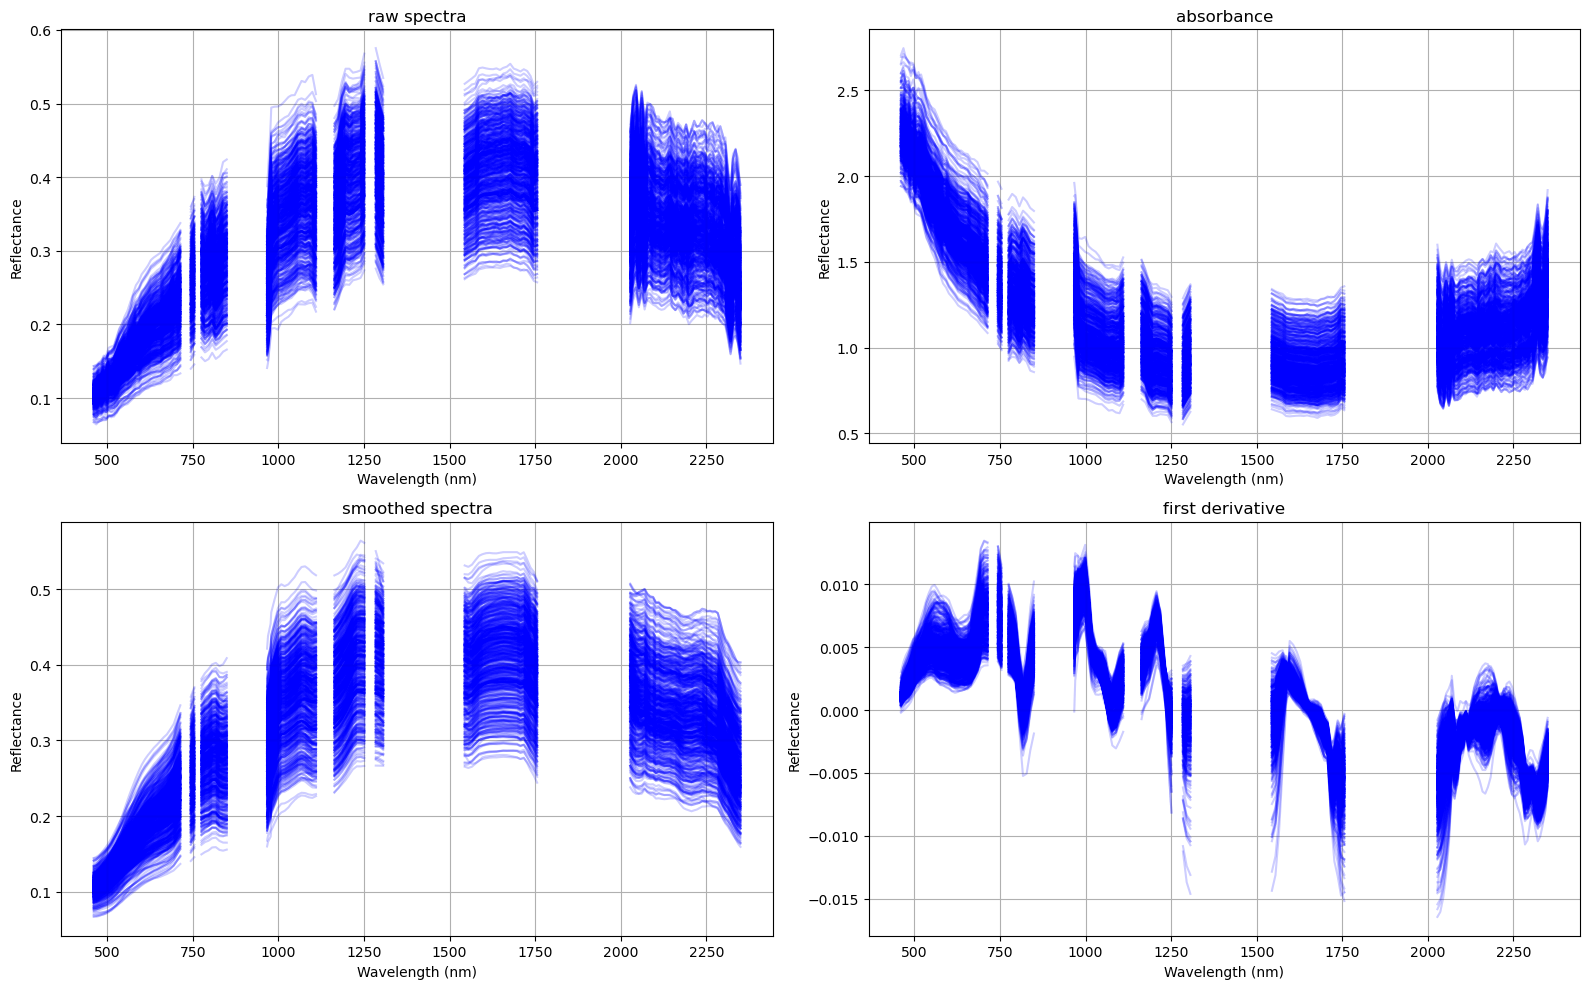

In [52]:
# Define the x-axis values (wavelengths) from the bands dictionary
x_values = bands_df[1].astype(float)

# Extract y-values (spectra only) from dataset_list
y_values_list = [data.iloc[:, 3:] for data in dataset_list.values()]

# Extract titles from transformation names
titles = [transformation.replace('_', ' ') for transformation in dataset_list.keys()]

# Plot using your custom plotting function
plotters.plot_spectra(
    x_values,
    y_values_list,
    titles=titles,
    xlabel='Wavelength (nm)',
    ylabel='Reflectance',
    alpha=0.1,
    color='blue'
)

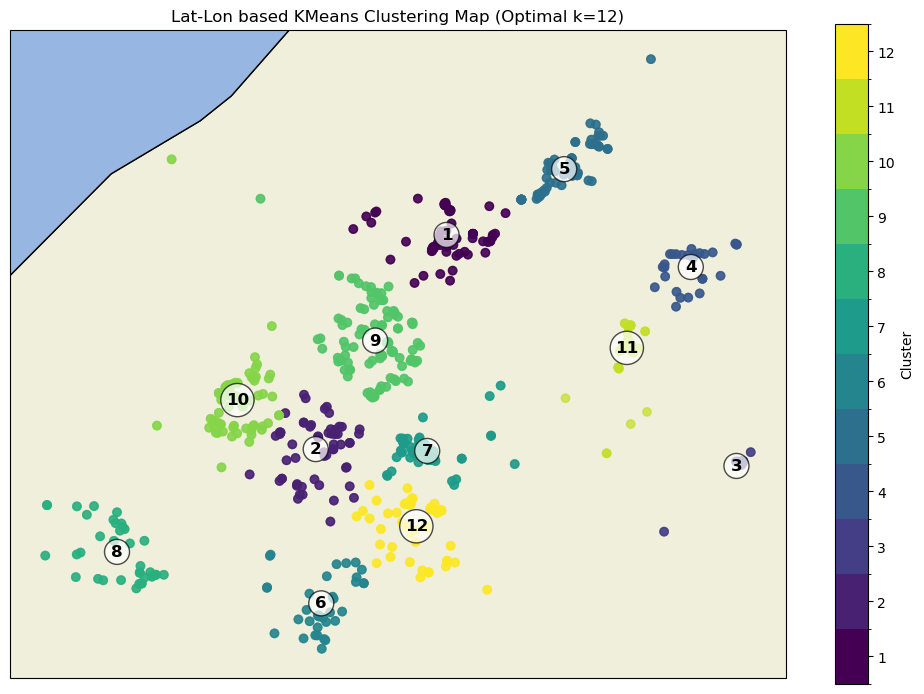

In [56]:
merged_dataset =merged_datasets[0]['raw_spectra']
helper.kmeans_clustering_map(merged_dataset, feature_cols=['Longitude_X', 'Latitude_Y'], cmap='viridis', title='Lat-Lon based KMeans Clustering Map', k_range=(12,12))